# 1. Import data and packages

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [239]:
etf = pd.read_csv('dataset/US_data_ETFs.csv')
etf.head()

,PERMNO,date,SHRCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT
0,10113,2010-07-30,73,AADR,ADVISORSHARES TRUST,53202,25.1000,1018.0,C,100.0
1,10113,2010-08-31,73,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0,0.009761,100.0
2,10113,2010-09-30,73,AADR,ADVISORSHARES TRUST,53202,28.2100,1912.0,0.113040,225.0
3,10113,2010-10-29,73,AADR,ADVISORSHARES TRUST,53202,28.8593,1233.0,0.023017,275.0
4,10113,2010-11-30,73,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0,-0.019380,275.0


In [240]:
etf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386955 entries, 0 to 386954
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   PERMNO  386955 non-null  int64  
 1   date    386955 non-null  object 
 2   SHRCD   386955 non-null  int64  
 3   TICKER  386955 non-null  object 
 4   COMNAM  386955 non-null  object 
 5   PERMCO  386955 non-null  int64  
 6   PRC     385019 non-null  float64
 7   VOL     386783 non-null  float64
 8   RET     385019 non-null  object 
 9   SHROUT  386783 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 29.5+ MB


The ETF dataset has a total of 386955 data observations.

In [241]:
sp500 = pd.read_csv('dataset/US_data_SP500.csv')
sp500.head()

,date,sprtrn
0,31/01/2000,-0.050904
1,29/02/2000,-0.020108
2,31/03/2000,0.096720
3,28/04/2000,-0.030796
4,31/05/2000,-0.021915


In [242]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    300 non-null    object 
 1   sprtrn  300 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.8+ KB


In [243]:
# First, check the date range of the ETF data
etf['date'].min()

'2000-01-31'

In [244]:
# Then check the last date of the ETF data
etf['date'].max()

'2024-12-31'

In [245]:
# Check how many months the ETF data covers in total
etf['date'].nunique()

300

In [246]:
# Check how many ETFs there are in total
etf['PERMNO'].nunique()

5688

In [247]:
# Also check how many TICKERs there are
# TICKER can be renamed, so this count may differ from PERMNO
etf['TICKER'].nunique()

5739

In [248]:
# Check the date range of the S&P500 data
sp500['date'].min()

'26/02/2010'

In [249]:
# Then check the last date of the S&P500 data
sp500['date'].max()

'31/12/2024'

In [250]:
# Check how many months the S&P500 data covers in total
len(sp500)

300

# 2. Data check

## 2.1 Checking and Handling the Date Column

In [251]:
# Convert the date columns of etf and sp500 to datetime, then extract year and month into new columns
etf['date'] = pd.to_datetime(etf['date'], format='%Y-%m-%d', errors='coerce')
sp500['date'] = pd.to_datetime(sp500['date'], format='%d/%m/%Y', errors='coerce')

etf['year'] = etf['date'].dt.year
etf['month'] = etf['date'].dt.month
sp500['year'] = sp500['date'].dt.year
sp500['month'] = sp500['date'].dt.month

# Sort the data: etf by ticker then date, sp500 by date only
etf = etf.sort_values(['PERMNO', 'date'])
etf = etf.reset_index(drop=True)
sp500 = sp500.sort_values('date')
sp500 = sp500.reset_index(drop=True)

# Check the date column for missing values; an output of 0 means it is fine
print(etf['date'].isna().sum())
print(sp500['date'].isna().sum())

0
0


In [252]:
etf.head()

,PERMNO,date,SHRCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,year,month
0,10113,2010-07-30,73,AADR,ADVISORSHARES TRUST,53202,25.1000,1018.0,C,100.0,2010,7
1,10113,2010-08-31,73,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0,0.009761,100.0,2010,8
2,10113,2010-09-30,73,AADR,ADVISORSHARES TRUST,53202,28.2100,1912.0,0.113040,225.0,2010,9
3,10113,2010-10-29,73,AADR,ADVISORSHARES TRUST,53202,28.8593,1233.0,0.023017,275.0,2010,10
4,10113,2010-11-30,73,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0,-0.019380,275.0,2010,11


In [253]:
sp500.head()

,date,sprtrn,year,month
0,2000-01-31,-0.050904,2000,1
1,2000-02-29,-0.020108,2000,2
2,2000-03-31,0.096720,2000,3
3,2000-04-28,-0.030796,2000,4
4,2000-05-31,-0.021915,2000,5


In [254]:
# Check whether the same ETF appears twice on the same day in etf; an output of 0 means no duplicates
duplicate_permno_date = etf.duplicated(subset=['PERMNO', 'date']).sum()
print(duplicate_permno_date)

0


## 2.2 Processing SHRCD columns

In [255]:
# Check the unique value of SHRCD column
print(etf['SHRCD'].unique())

[73]


In [256]:
# We found that in the ETF dataset, the SHRCD of all ETFs is 73 (representing all ETFs and no other securities types), so we can directly delete the SHRCD column
etf = etf.drop(columns=['SHRCD'])

etf.head()

,PERMNO,date,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,year,month
0,10113,2010-07-30,AADR,ADVISORSHARES TRUST,53202,25.1000,1018.0,C,100.0,2010,7
1,10113,2010-08-31,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0,0.009761,100.0,2010,8
2,10113,2010-09-30,AADR,ADVISORSHARES TRUST,53202,28.2100,1912.0,0.113040,225.0,2010,9
3,10113,2010-10-29,AADR,ADVISORSHARES TRUST,53202,28.8593,1233.0,0.023017,275.0,2010,10
4,10113,2010-11-30,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0,-0.019380,275.0,2010,11


## 2.3 Processing PRC columns

In [257]:
# Check the data quality of the PRC column: any missing values, negative values, or zeros
# We found 19628 negative values; in the CRSP database a negative price represents the bid-ask midpoint, not a truly negative price, so it needs handling later
print((etf['PRC'] > 0).all())
print(etf['PRC'].isna().sum())
print((etf['PRC'] < 0).sum())
print((etf['PRC'] == 0).sum())

False
1936
19628
0


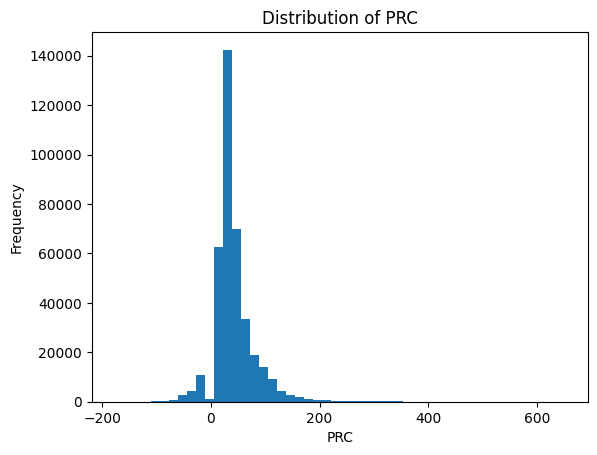

In [258]:
# Plot a histogram to see the distribution of PRC; we can see there are some negative values
plt.hist(etf['PRC'].dropna(), bins=50)
plt.title('Distribution of PRC')
plt.xlabel('PRC')
plt.ylabel('Frequency')
plt.show()

In [259]:
# The negative values in PRC are actually bid-ask midpoints, so just take the absolute value and store it in a new column PRC_abs
# Also, a price of 0 indicates missing data, so replace it with NaN
etf['PRC_abs'] = etf['PRC'].abs()
etf.loc[etf['PRC_abs'] == 0, 'PRC_abs'] = np.nan

# Check again after processing; negatives should be gone and the number of missing values should remain 1936
print((etf['PRC_abs'] > 0).all())
print(etf['PRC_abs'].isna().sum())
print((etf['PRC_abs'] < 0).sum())
print((etf['PRC_abs'] == 0).sum())

False
1936
0
0


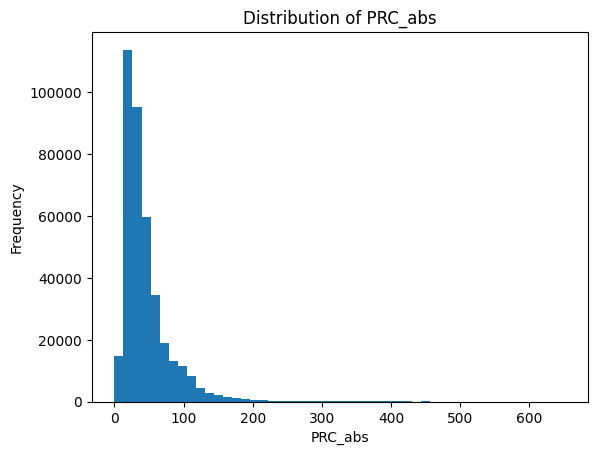

In [260]:
# Plot the distribution again; there are no negative values now
plt.hist(etf['PRC_abs'].dropna(), bins=50)
plt.title('Distribution of PRC_abs')
plt.xlabel('PRC_abs')
plt.ylabel('Frequency')
plt.show()

## 2.4 Processing the RET column

In [261]:
# Inspect the RET (return) column; it is currently of object type, which means it contains non-numeric values
# Characters like "C" are common in CRSP and need to be found and converted to numbers
print(etf['RET'].dtype)
# How many missing values does RET have?
print(etf['RET'].isna().sum())
# How many non-numeric observations are in RET?
non_numeric_ret = etf.loc[pd.to_numeric(etf['RET'], errors='coerce').isna() & etf['RET'].notna(), 'RET']
print(len(non_numeric_ret))

object
1936
5656


In [262]:
# First back up the original RET for later comparison and checking
etf['RET_raw'] = etf['RET']

# Convert RET to numeric; non-numeric characters like "C" will automatically become NaN
etf['RET'] = pd.to_numeric(etf['RET'], errors='coerce')

# After conversion the number of missing values goes from 1936 to 7592; the extra ones are the non-numeric characters turned into NaN
print(etf['RET'].dtype)
print(etf['RET'].isna().sum())

float64
7592


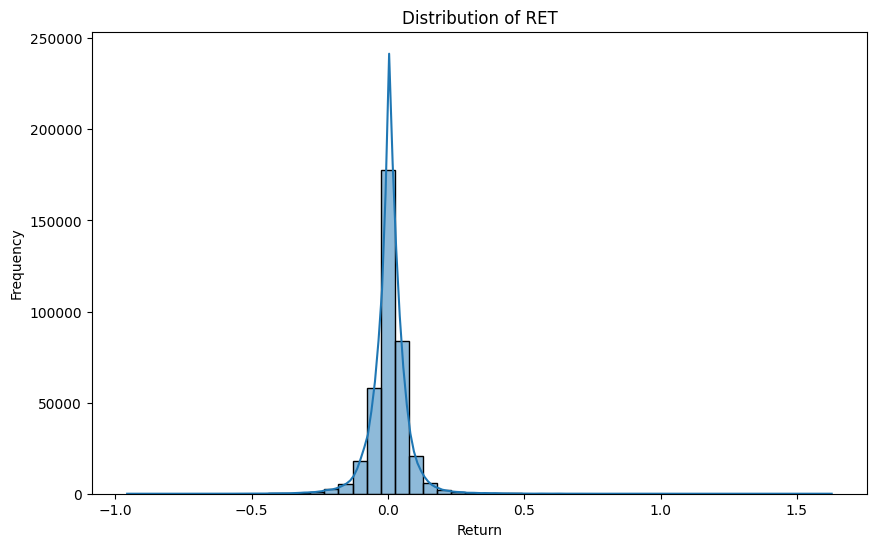

In [263]:
# Plot the distribution of RET; most returns are concentrated near 0, as expected
plt.figure(figsize=(10, 6))
sns.histplot(etf['RET'], bins=50, kde=True)
plt.title('Distribution of RET')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()

Conclusion: There are no missing codes for -66/-77/-88/-99 values in the dataset, nor are there any outliers with RET<-1.

## 2.5 Checking the SHROUT column

In [264]:
# Inspect the SHROUT (shares outstanding) column; the unit is thousands of shares
# No negatives or zeros means the data quality is acceptable; there are 172 missing values to handle later
print(etf['SHROUT'].dtype)
print(etf['SHROUT'].isna().sum())
print((etf['SHROUT'] == 0).sum())
print((etf['SHROUT'] < 0).sum())

float64
172
0
0


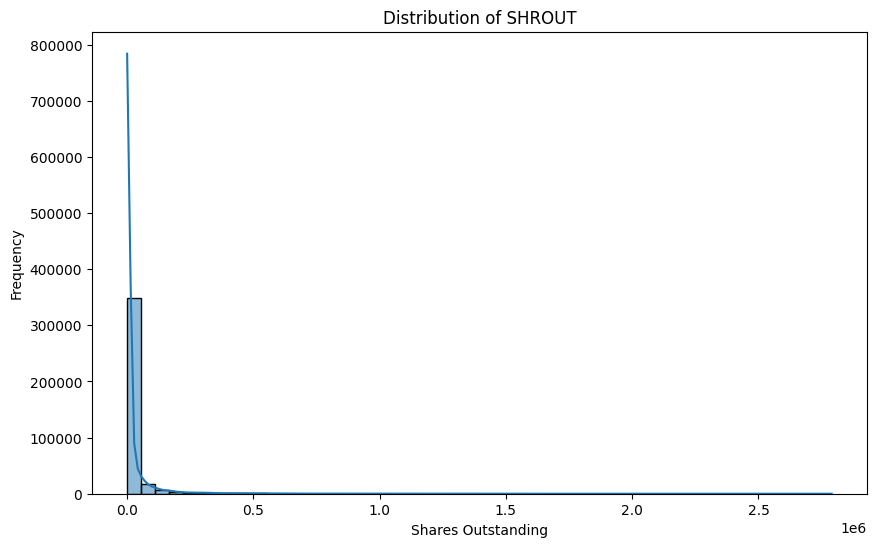

In [265]:
# Plot the distribution; the data is heavily right-skewed, most ETFs have relatively few shares outstanding while a few are very large
plt.figure(figsize=(10, 6))
sns.histplot(etf['SHROUT'], bins=50, kde=True)
plt.title('Distribution of SHROUT')
plt.xlabel('Shares Outstanding')
plt.ylabel('Frequency')
plt.show()

# SHROUT is publicly outstanding shares, in units of thousand shares
# Both AUM and flow depend on SHROUT, so we cannot casually impute it with the mean or median
# We do not drop the missing values immediately here; they will be dropped as needed when computing AUM, flow, and during modeling

## 2.6 Checking the VOL column

In [266]:
# Inspect the basic situation of the VOL (volume) column
# There are 945 zeros, meaning no trading on those days; keep this in mind for later calculations
print(etf['VOL'].dtype)
print(etf['VOL'].isna().sum())
print((etf['VOL'] == 0).sum())
print((etf['VOL'] < 0).sum())

float64
172
945
0


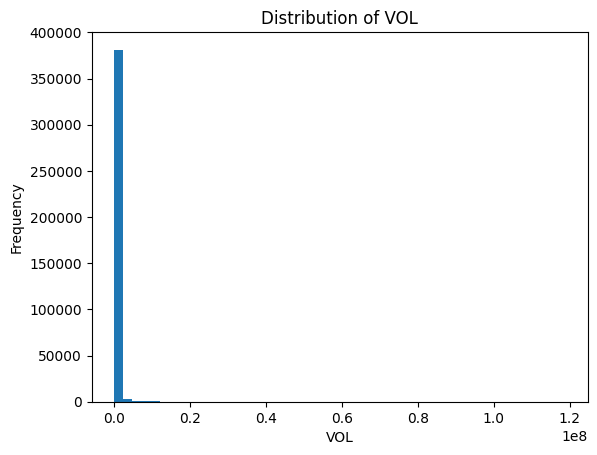

In [267]:
# Plot the distribution; volume is also heavily right-skewed, mostly concentrated near 0 with a few trading days having very large volume
plt.hist(etf['VOL'].dropna(), bins=50)
plt.title('Distribution of VOL')
plt.xlabel('VOL')
plt.ylabel('Frequency')
plt.show()

## 2.7 Summary

This section first conducted a data quality check and cleaning on the monthly data of ETFs (386955 records, covering 5688 ETFs, with a time range from January 2000 to December 2024) and S&P 500 data. The results indicate that the overall quality of the two data sets is high, but there are still a few issues such as missing values, abnormal encoding, and skewed variable distribution.

In ETF data, date variables have been uniformly converted to standard date format, and it has been confirmed that there are no missing or duplicate (PERMNO, date) observations. SHRCD remained at 73 throughout the sample period, being same, therefore it was deleted. The price variable (PRC) has some missing values, negative values, and zero values, where negative values are the recording method used by CRSP to represent the buying and selling middle price. Therefore, the absolute value is uniformly taken to generate PRC_abs, and zero values are treated as missing. The return rate variable (RET) originally contained some non numeric codes (such as "C"), but was converted to a numeric type while retaining the original variables, and no abnormal extreme return records were found. SHROUT and VOL both have a small number of missing values, among which the trading volume (VOL) also includes some months with zero trading volume, which will be further processed in the variable construction stage.

Overall, after cleaning, the data has formed monthly data with consistent structure and no duplicate records. The main data quality issues, such as negative prices, non numeric return codes, and missing values, have been addressed or marked, laying the foundation for subsequent variable construction and empirical analysis.

# 3. Constructing new variables

In [268]:
etf.head()

,PERMNO,date,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,year,month,PRC_abs,RET_raw
0,10113,2010-07-30,AADR,ADVISORSHARES TRUST,53202,25.1000,1018.0,NaN,100.0,2010,7,25.1000,C
1,10113,2010-08-31,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0,0.009761,100.0,2010,8,25.3450,0.009761
2,10113,2010-09-30,AADR,ADVISORSHARES TRUST,53202,28.2100,1912.0,0.113040,225.0,2010,9,28.2100,0.113040
3,10113,2010-10-29,AADR,ADVISORSHARES TRUST,53202,28.8593,1233.0,0.023017,275.0,2010,10,28.8593,0.023017
4,10113,2010-11-30,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0,-0.019380,275.0,2010,11,28.3000,-0.019380


## 3.1 AUM

In [269]:
# Make sure the data is sorted by ETF and date
etf = etf.sort_values(['PERMNO', 'date']).reset_index(drop=True)

# AUM = PRC_abs * SHROUT
# SHROUT is in thousand shares, so multiply by 1000 here
etf['AUM'] = etf['PRC_abs'] * etf['SHROUT'] * 1000

## 3.2 lag_AUM

In [270]:
# Previous-period AUM
etf['lag_AUM'] = etf.groupby('PERMNO')['AUM'].shift(1)

## 3.3 Flow

In [271]:
# Flow = monthly change in SHROUT * current price
# In the assignment, flow is defined as monthly change in SHROUT * PRC, i.e. delta_SHROUT * PRC
# SHROUT is in thousand shares, so multiply by 1000 here
etf['lag_SHROUT'] = etf.groupby('PERMNO')['SHROUT'].shift(1)
etf['delta_SHROUT'] = etf['SHROUT'] - etf['lag_SHROUT']
etf['flow'] = etf['delta_SHROUT'] * etf['PRC_abs'] * 1000

## 3.4 FlowRate

In [272]:
# Net inflow rate: net inflow amount divided by previous-period AUM
# This allows a fairer comparison across ETFs of different sizes.
etf['FlowRate'] = etf['flow'] / etf['lag_AUM']

## 3.5 lag_ret_1, lag_ret_2, lag_ret_3

In [273]:
# ETF returns lagged by one, two, and three periods
# Flow-performance sensitivity mainly measures the sensitivity of ETF flow to past returns
# lag_ret_2 and lag_ret_3 are used to build different regression models, testing whether earlier returns also affect fund flow
etf['lag_ret_1'] = etf.groupby('PERMNO')['RET'].shift(1)
etf['lag_ret_2'] = etf.groupby('PERMNO')['RET'].shift(2)
etf['lag_ret_3'] = etf.groupby('PERMNO')['RET'].shift(3)

## 3.6 flow_positive

In [274]:
# For logistic regression: determine whether flow is positive
# If flow is missing, keep flow_positive missing as well, to avoid mislabeling the first observation as 0
etf['flow_positive'] = np.where(etf['flow'].notna(), (etf['flow'] > 0).astype(int), np.nan)

In [275]:
# Check the new variables
display(etf[['PERMNO', 'TICKER', 'date', 'PRC', 'PRC_abs', 'SHROUT', 'lag_SHROUT', 'delta_SHROUT', 'AUM', 
             'lag_AUM', 'flow', 'FlowRate', 'RET', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 
             'flow_positive', 'year', 'month']].head())


,PERMNO,TICKER,date,PRC,PRC_abs,SHROUT,lag_SHROUT,delta_SHROUT,AUM,lag_AUM,flow,FlowRate,RET,lag_ret_1,lag_ret_2,lag_ret_3,flow_positive,year,month
0,10113,AADR,2010-07-30,25.1000,25.1000,100.0,NaN,NaN,2510000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010,7
1,10113,AADR,2010-08-31,25.3450,25.3450,100.0,100.0,0.0,2534500.0,2510000.0,0.0,0.000000,0.009761,NaN,NaN,NaN,0.0,2010,8
2,10113,AADR,2010-09-30,28.2100,28.2100,225.0,100.0,125.0,6347250.0,2534500.0,3526250.0,1.391300,0.113040,0.009761,NaN,NaN,1.0,2010,9
3,10113,AADR,2010-10-29,28.8593,28.8593,275.0,225.0,50.0,7936307.5,6347250.0,1442965.0,0.227337,0.023017,0.113040,0.009761,NaN,1.0,2010,10
4,10113,AADR,2010-11-30,28.3000,28.3000,275.0,275.0,0.0,7782500.0,7936307.5,0.0,0.000000,-0.019380,0.023017,0.113040,0.009761,0.0,2010,11


# 4. Data preprocessing

## 4.1 Merging the two tables

In [276]:
# Make sure the date columns are in datetime format
etf['date'] = pd.to_datetime(etf['date'], errors='coerce')
sp500['date'] = pd.to_datetime(sp500['date'], errors='coerce')

# Use year-month as the merge key, so mismatched month-end dates do not prevent matching
etf['year_month'] = etf['date'].dt.to_period('M')
sp500['year_month'] = sp500['date'].dt.to_period('M')

# Take only the two needed columns from sp500 and rename the return column to mkt_ret
sp500_merge = sp500[['year_month', 'sprtrn']].copy()
sp500_merge = sp500_merge.rename(columns={'sprtrn': 'mkt_ret'})

# Confirm sp500 has only one record per month; an output of 0 means no duplicates
print(sp500_merge.duplicated(subset=['year_month']).sum())

# Merge etf and sp500 by year-month; etf can have multiple records per month while sp500 has only one
etf = etf.merge(sp500_merge, on='year_month', how='left', validate='many_to_one')

# Flow prediction can only use known information, so use the previous period's market return
etf = etf.sort_values(['PERMNO', 'date'])
etf = etf.reset_index(drop=True)
etf['lag_mkt_ret'] = etf.groupby('PERMNO')['mkt_ret'].shift(1)

# Check the merge result; missing values in lag_mkt_ret are normal since each fund has no prior data in its first month
print(len(etf))
print(etf['mkt_ret'].isna().sum())
print(etf['lag_mkt_ret'].isna().sum())

0
386955
0
5688


In [277]:
# Take a look at the merged data
etf.head()

,PERMNO,date,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,year,...,delta_SHROUT,flow,FlowRate,lag_ret_1,lag_ret_2,lag_ret_3,flow_positive,year_month,mkt_ret,lag_mkt_ret
0,10113,2010-07-30,AADR,ADVISORSHARES TRUST,53202,25.1000,1018.0,NaN,100.0,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-07,0.068778,NaN
1,10113,2010-08-31,AADR,ADVISORSHARES TRUST,53202,25.3450,624.0,0.009761,100.0,2010,...,0.0,0.0,0.000000,NaN,NaN,NaN,0.0,2010-08,-0.047449,0.068778
2,10113,2010-09-30,AADR,ADVISORSHARES TRUST,53202,28.2100,1912.0,0.113040,225.0,2010,...,125.0,3526250.0,1.391300,0.009761,NaN,NaN,1.0,2010-09,0.087551,-0.047449
3,10113,2010-10-29,AADR,ADVISORSHARES TRUST,53202,28.8593,1233.0,0.023017,275.0,2010,...,50.0,1442965.0,0.227337,0.113040,0.009761,NaN,1.0,2010-10,0.036856,0.087551
4,10113,2010-11-30,AADR,ADVISORSHARES TRUST,53202,28.3000,268.0,-0.019380,275.0,2010,...,0.0,0.0,0.000000,0.023017,0.113040,0.009761,0.0,2010-11,-0.002290,0.036856


## 4.2 Handling distributions

In [278]:
from scipy.stats.mstats import winsorize

### 4.2.1 Handling the distribution of AUM

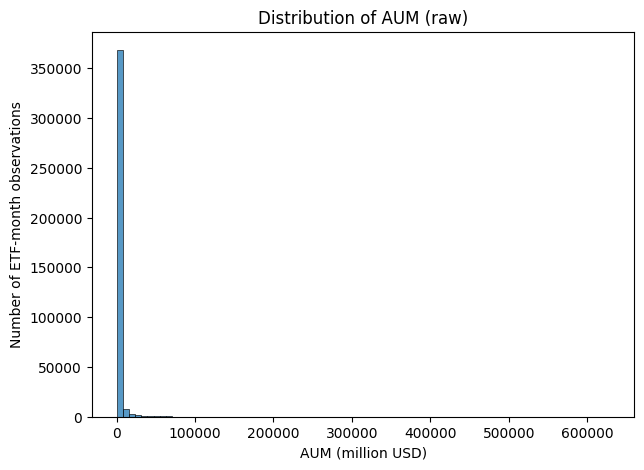

In [279]:
# Plot the raw distribution of AUM; it is heavily right-skewed, most ETFs are small while a few giant ETFs stretch the plot
plt.figure(figsize=(7, 5))
sns.histplot(etf['AUM'].dropna() / 1_000_000, bins=80, kde=False)
plt.title('Distribution of AUM (raw)')
plt.xlabel('AUM (million USD)')
plt.ylabel('Number of ETF-month observations')
plt.show()

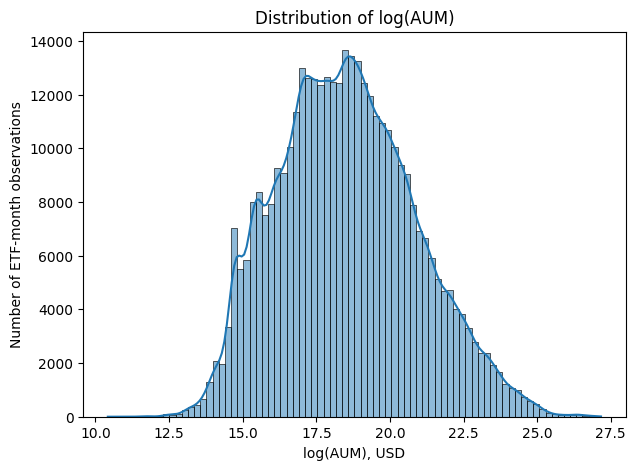

In [280]:
# After taking logs the distribution looks much more normal, close to Gaussian, so log(AUM) is more appropriate for later modeling
plt.figure(figsize=(7, 5))
sns.histplot(np.log(etf.loc[etf['AUM'] > 0, 'AUM']), bins=80, kde=True)
plt.title('Distribution of log(AUM)')
plt.xlabel('log(AUM), USD')
plt.ylabel('Number of ETF-month observations')
plt.show()

In [281]:
# AUM and lag_AUM: heavily right-skewed, take logs
etf['log_AUM'] = np.log(etf['AUM'])
etf['lag_log_AUM'] = np.log(etf['lag_AUM'])

### 4.2.2 Handling the distribution of VOL

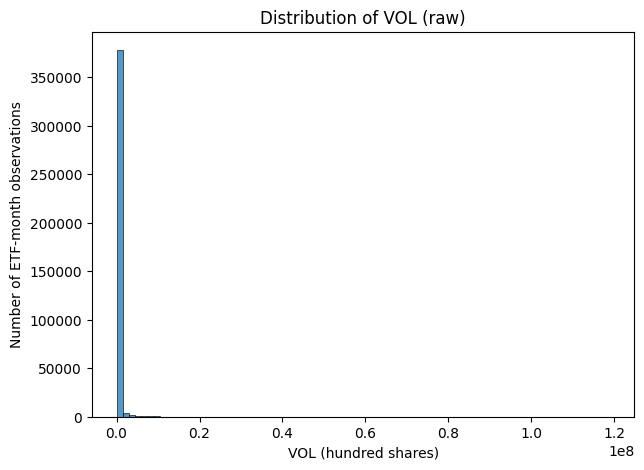

In [282]:
# Plot the raw distribution of VOL; like AUM it is heavily right-skewed, almost everything piles up near 0 and little can be seen
plt.figure(figsize=(7, 5))
sns.histplot(etf['VOL'].dropna(), bins=80, kde=False)
plt.title('Distribution of VOL (raw)')
plt.xlabel('VOL (hundred shares)')
plt.ylabel('Number of ETF-month observations')
plt.show()

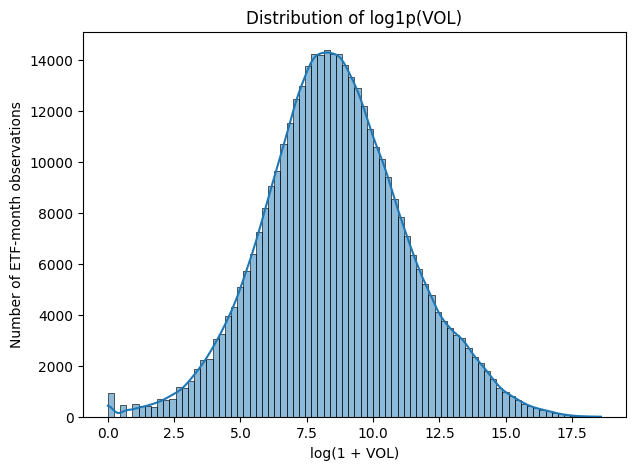

In [283]:
# Use log1p instead of log because VOL has zeros and log(0) errors out; log1p = log(1 + VOL) handles 0
# After taking logs the distribution looks much better
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(etf['VOL'].dropna()), bins=80, kde=True)
plt.title('Distribution of log1p(VOL)')
plt.xlabel('log(1 + VOL)')
plt.ylabel('Number of ETF-month observations')
plt.show()

In [284]:
# VOL: heavily right-skewed, use log1p, which can handle VOL = 0
etf['log_VOL'] = np.log1p(etf['VOL'])
etf['lag_log_VOL_1'] = etf.groupby('PERMNO')['log_VOL'].shift(1)

### 4.2.3 Winsorize FlowRate

In [285]:
# Define a winsorizing function that caps the extreme values of FlowRate at the 1% and 99% percentiles, to prevent outliers from affecting the analysis
# Skip missing values and winsorize only the part with data
def winsorize_series(s, lower=0.01, upper=0.01):
    s_new = s.copy()
    mask = s_new.notna()
    s_new.loc[mask] = winsorize(s_new.loc[mask], limits=[lower, upper])
    return s_new

etf['FlowRate_winsor'] = winsorize_series(etf['FlowRate'], lower=0.01, upper=0.01)

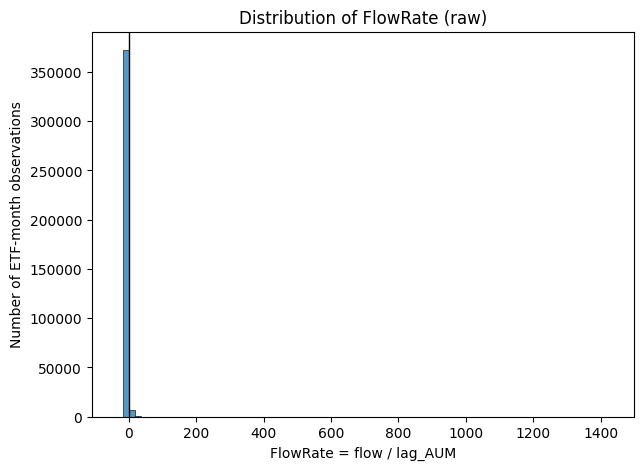

In [286]:
# Raw FlowRate distribution; extreme values stretch the plot badly, with almost all data piled up near 0
plt.figure(figsize=(7, 5))
sns.histplot(etf['FlowRate'].replace([np.inf, -np.inf], np.nan).dropna(), bins=80, kde=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Distribution of FlowRate (raw)')
plt.xlabel('FlowRate = flow / lag_AUM')
plt.ylabel('Number of ETF-month observations')
plt.show()

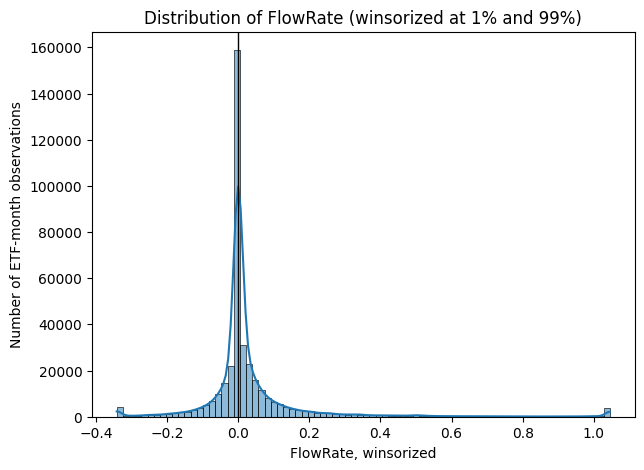

In [287]:
# After winsorizing the distribution looks much more normal; we can see most ETFs have flow rates near 0
plt.figure(figsize=(7, 5))
sns.histplot(etf['FlowRate_winsor'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.title('Distribution of FlowRate (winsorized at 1% and 99%)')
plt.xlabel('FlowRate, winsorized')
plt.ylabel('Number of ETF-month observations')
plt.show()

### 4.2.4 Checking the distributions of the return variables

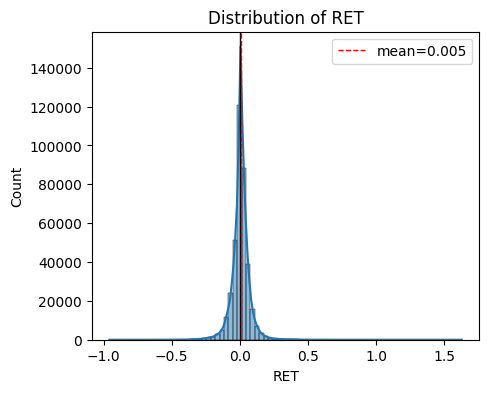

In [288]:
# Plot the distribution of RET (current return); it is concentrated near 0 with a mean of about 0.005
plt.figure(figsize=(5, 4))
sns.histplot(etf['RET'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(etf['RET'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={etf["RET"].mean():.3f}')
plt.title('Distribution of RET')
plt.xlabel('RET')
plt.legend()
plt.show()

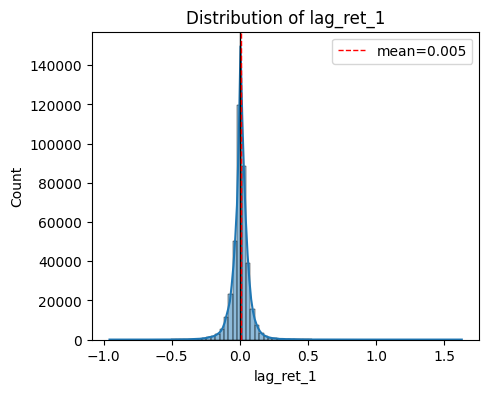

In [289]:
# Plot the distribution of lag_ret_1 (return lagged by one period)
plt.figure(figsize=(5, 4))
sns.histplot(etf['lag_ret_1'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(etf['lag_ret_1'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={etf["lag_ret_1"].mean():.3f}')
plt.title('Distribution of lag_ret_1')
plt.xlabel('lag_ret_1')
plt.legend()
plt.show()

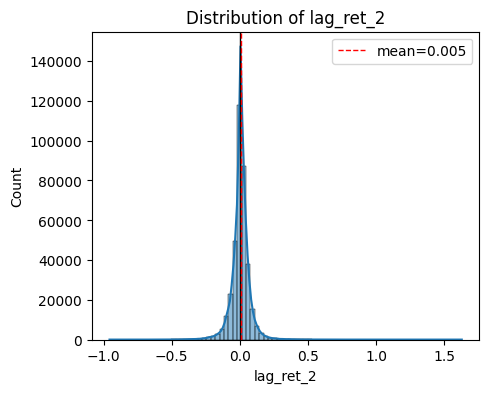

In [290]:
# Plot the distribution of lag_ret_2 (return lagged by two periods)
plt.figure(figsize=(5, 4))
sns.histplot(etf['lag_ret_2'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(etf['lag_ret_2'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={etf["lag_ret_2"].mean():.3f}')
plt.title('Distribution of lag_ret_2')
plt.xlabel('lag_ret_2')
plt.legend()
plt.show()

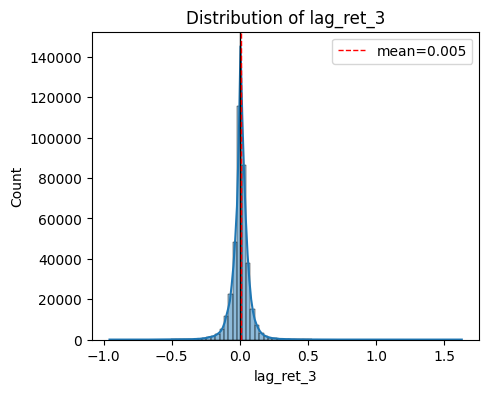

In [291]:
# Plot the distribution of lag_ret_3 (return lagged by three periods)
plt.figure(figsize=(5, 4))
sns.histplot(etf['lag_ret_3'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(etf['lag_ret_3'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={etf["lag_ret_3"].mean():.3f}')
plt.title('Distribution of lag_ret_3')
plt.xlabel('lag_ret_3')
plt.legend()
plt.show()

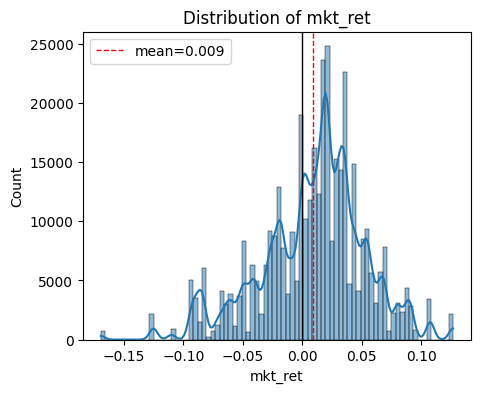

In [292]:
# Plot the distribution of mkt_ret (market return); this distribution is much narrower than ETF returns, indicating the overall market is less volatile than a single ETF
plt.figure(figsize=(5, 4))
sns.histplot(etf['mkt_ret'].dropna(), bins=80, kde=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(etf['mkt_ret'].mean(), color='red', linewidth=1, linestyle='--', label=f'mean={etf["mkt_ret"].mean():.3f}')
plt.title('Distribution of mkt_ret')
plt.xlabel('mkt_ret')
plt.legend()
plt.show()

## 4.3 Heatmap

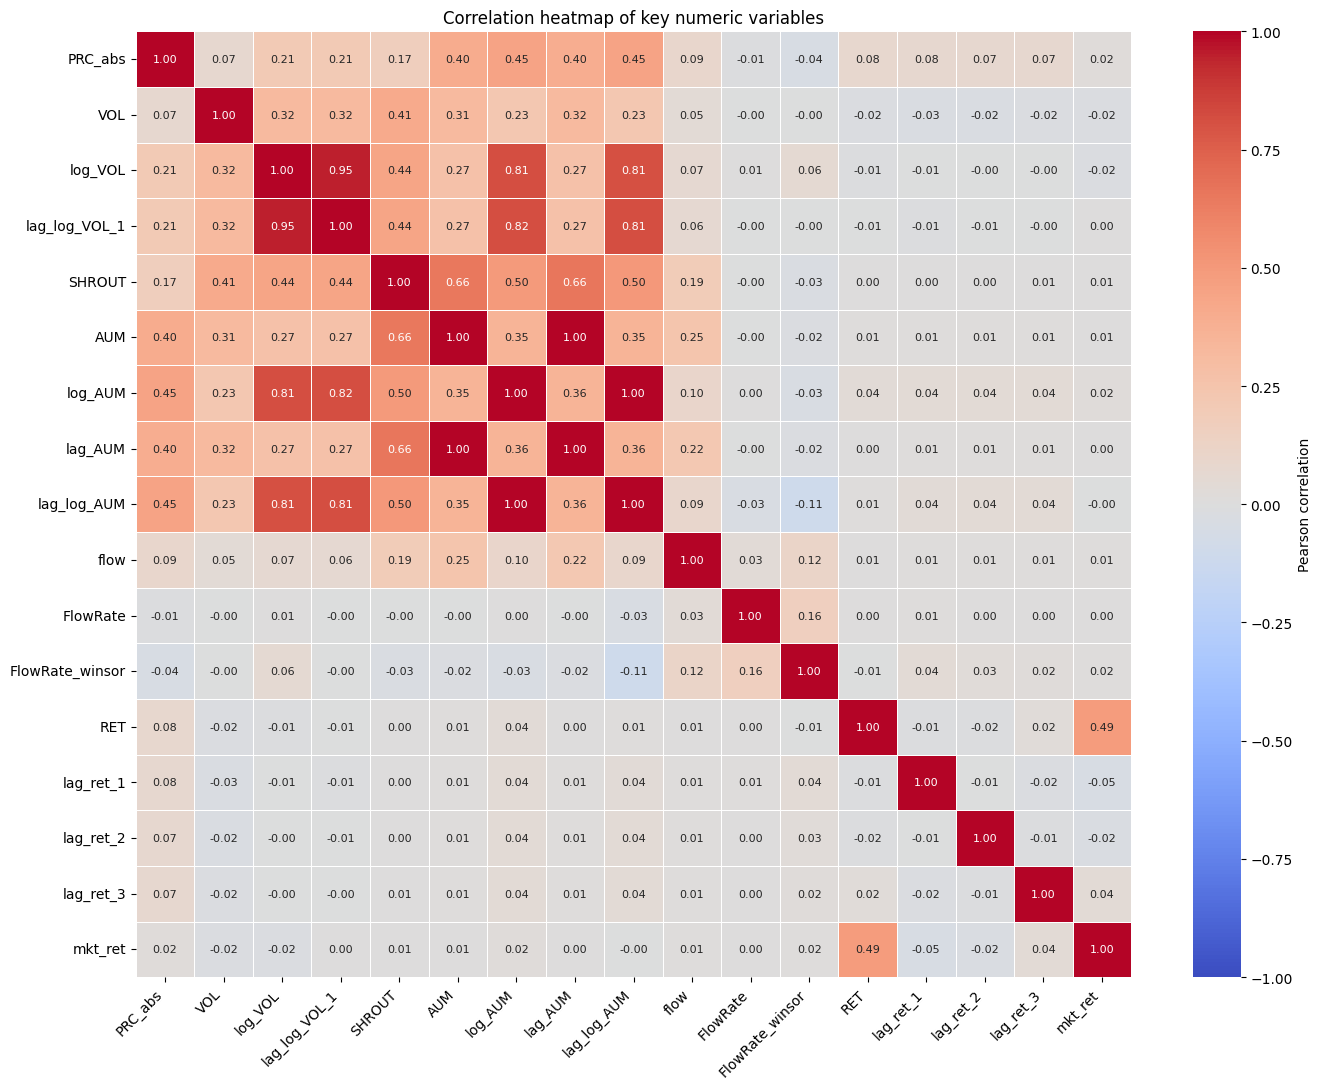

In [293]:
# 4.3 Heatmap
# Examine the pairwise correlations among all relevant numeric variables so far

heatmap_cols = [
    # Basic price / volume / shares / size
    'PRC_abs',
    'VOL', 'log_VOL', 'lag_log_VOL_1',
    'SHROUT',
    'AUM', 'log_AUM',
    'lag_AUM', 'lag_log_AUM',

    # Fund flow
    'flow',
    'FlowRate', 'FlowRate_winsor',

    # ETF returns (core explanatory variables)
    'RET',
    'lag_ret_1', 'lag_ret_2', 'lag_ret_3',

    # Market return
    'mkt_ret',
]


# Compute the correlation matrix
# Convert inf / -inf to NaN, to prevent extreme FlowRate values when lag_AUM≈0 from contaminating the correlations
corr_input = etf[heatmap_cols].replace([np.inf, -np.inf], np.nan)
corr_matrix = corr_input.corr()

# Plot the heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Pearson correlation'}
)
plt.title('Correlation heatmap of key numeric variables')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 5. Task 1: Flow-performance sensitivity regression analysis

## 5.1 OLS regression modeling

In [294]:
import statsmodels.api as sm

# Data preparation: ensure sorting + construct lag_FlowRate_winsor (used by Model 5)
etf = etf.sort_values(['PERMNO', 'date']).reset_index(drop=True)
etf['lag_FlowRate_winsor'] = etf.groupby('PERMNO')['FlowRate_winsor'].shift(1)

In [295]:
# Find an ETF with enough data (at least 120 months) and the largest size for a case study

# First count how many valid records each ETF has, along with its average AUM
candidate_etfs = etf.dropna(subset=['FlowRate_winsor', 'lag_ret_1'])
candidate_etfs = candidate_etfs.groupby(['PERMNO', 'TICKER', 'COMNAM'], as_index=False).agg(
    n_obs=('FlowRate_winsor', 'size'),
    avg_AUM=('AUM', 'mean')
)

# Keep only ETFs with more than 120 months of data, then sort by average AUM from largest to smallest
candidate_etfs = candidate_etfs[candidate_etfs['n_obs'] >= 120]
candidate_etfs = candidate_etfs.sort_values(['avg_AUM', 'n_obs'], ascending=False)

# Take the first one, i.e. the largest ETF
selected_permno = candidate_etfs.iloc[0]['PERMNO']
selected_ticker = candidate_etfs.iloc[0]['TICKER']
selected_name = candidate_etfs.iloc[0]['COMNAM']
print(selected_ticker)
print(selected_permno)
print(selected_name)

# Extract this ETF's data separately and sort it by date
reg_data = etf.loc[etf['PERMNO'] == selected_permno].copy()
reg_data = reg_data.sort_values('date')
reg_data = reg_data.reset_index(drop=True)

SPY
84398
SPDR S & P 500 E T F TRUST


In [296]:
# Run the first model: predict flow rate using only the previous period's return
df1 = reg_data[['FlowRate_winsor', 'lag_ret_1']].dropna()
y1 = df1['FlowRate_winsor'].astype(float)
X1 = sm.add_constant(df1['lag_ret_1'].astype(float))
fit1 = sm.OLS(y1, X1).fit(cov_type='HC3')
print(fit1.summary())

                            OLS Regression Results                            
Dep. Variable:        FlowRate_winsor   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     5.184
Date:                Fri, 29 May 2026   Prob (F-statistic):             0.0235
Time:                        17:25:47   Log-Likelihood:                 265.41
No. Observations:                 299   AIC:                            -526.8
Df Residuals:                     297   BIC:                            -519.4
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0167      0.007      2.556      0.0

In [297]:
# Run the second model: add returns lagged by two and three periods
df2 = reg_data[['FlowRate_winsor', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3']].dropna()
y2 = df2['FlowRate_winsor'].astype(float)
X2 = sm.add_constant(df2[['lag_ret_1', 'lag_ret_2', 'lag_ret_3']].astype(float))
fit2 = sm.OLS(y2, X2).fit(cov_type='HC3')
print(fit2.summary())

                            OLS Regression Results                            
Dep. Variable:        FlowRate_winsor   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.796
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.148
Time:                        17:25:47   Log-Likelihood:                 326.68
No. Observations:                 297   AIC:                            -645.4
Df Residuals:                     293   BIC:                            -630.6
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0134      0.005      2.496      0.0

In [298]:
# Run the third model: also add the previous period's market return
df3 = reg_data[['FlowRate_winsor', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret']].dropna()
y3 = df3['FlowRate_winsor'].astype(float)
X3 = sm.add_constant(df3[['lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret']].astype(float))
fit3 = sm.OLS(y3, X3).fit(cov_type='HC3')
print(fit3.summary())

                            OLS Regression Results                            
Dep. Variable:        FlowRate_winsor   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.434
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.223
Time:                        17:25:47   Log-Likelihood:                 327.67
No. Observations:                 297   AIC:                            -645.3
Df Residuals:                     292   BIC:                            -626.9
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0089      0.007      1.303      

In [299]:
# Run the fourth model: also add fund size and liquidity
df4 = reg_data[['FlowRate_winsor', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret', 'lag_log_AUM', 'lag_log_VOL_1']].dropna()
y4 = df4['FlowRate_winsor'].astype(float)
X4 = sm.add_constant(df4[['lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret', 'lag_log_AUM', 'lag_log_VOL_1']].astype(float))
fit4 = sm.OLS(y4, X4).fit(cov_type='HC3')
print(fit4.summary())

                            OLS Regression Results                            
Dep. Variable:        FlowRate_winsor   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.801
Date:                Fri, 29 May 2026   Prob (F-statistic):             0.0988
Time:                        17:25:47   Log-Likelihood:                 331.16
No. Observations:                 297   AIC:                            -648.3
Df Residuals:                     290   BIC:                            -622.5
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.3600      0.229      1.572

In [300]:
# Run the fifth model: also add the previous period's flow rate to check for flow persistence
df5 = reg_data[['FlowRate_winsor', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret', 'lag_log_AUM', 'lag_log_VOL_1', 'lag_FlowRate_winsor']].dropna()
y5 = df5['FlowRate_winsor'].astype(float)
X5 = sm.add_constant(df5[['lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret', 'lag_log_AUM', 'lag_log_VOL_1', 'lag_FlowRate_winsor']].astype(float))
fit5 = sm.OLS(y5, X5).fit(cov_type='HC3')
print(fit5.summary())

                            OLS Regression Results                            
Dep. Variable:        FlowRate_winsor   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1.618
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.130
Time:                        17:25:47   Log-Likelihood:                 332.36
No. Observations:                 297   AIC:                            -648.7
Df Residuals:                     289   BIC:                            -619.2
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3783    

In [301]:
all_vars = ['const', 'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret', 'lag_log_AUM', 'lag_log_VOL_1', 'lag_FlowRate_winsor']
model_names = ['(1) Baseline', '(2) + multiple lagged returns', '(3) + lagged market return', '(4) + fund size & liquidity', '(5) + flow persistence']

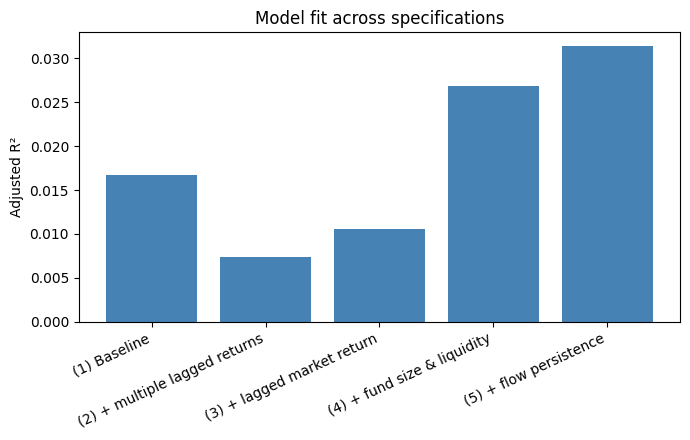

In [302]:
# Plot the Adjusted R² across models to see whether adding variables improves explanatory power
adj_r2_values = [fit1.rsquared_adj, fit2.rsquared_adj, fit3.rsquared_adj, fit4.rsquared_adj, fit5.rsquared_adj]

plt.figure(figsize=(7, 4.5))
plt.bar(range(5), adj_r2_values, color='steelblue')
plt.xticks(range(5), model_names, rotation=25, ha='right')
plt.ylabel('Adjusted R²')
plt.title('Model fit across specifications')
plt.tight_layout()
plt.show()

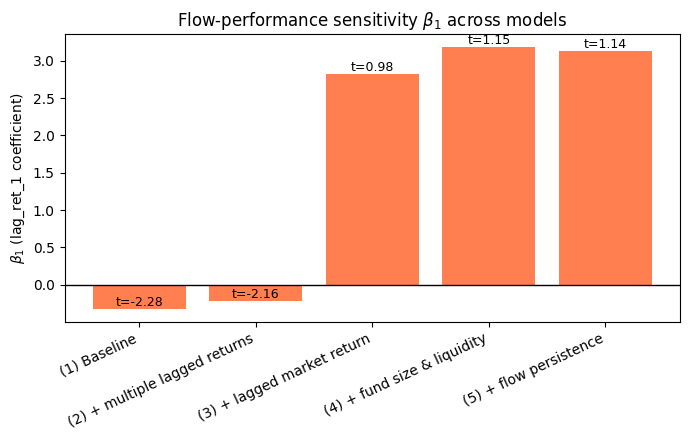

In [303]:
# Plot the change in the lag_ret_1 coefficient (β1) across models to see whether it changes as new variables are added
# Annotate the t-statistic above each bar; after adding the market return β1 flips sign, indicating an earlier omitted-variable problem
beta1_values = [fit1.params['lag_ret_1'], fit2.params['lag_ret_1'], fit3.params['lag_ret_1'], fit4.params['lag_ret_1'], fit5.params['lag_ret_1']]
beta1_tstats = [fit1.tvalues['lag_ret_1'], fit2.tvalues['lag_ret_1'], fit3.tvalues['lag_ret_1'], fit4.tvalues['lag_ret_1'], fit5.tvalues['lag_ret_1']]

plt.figure(figsize=(7, 4.5))
plt.bar(range(5), beta1_values, color='coral')
plt.text(0, beta1_values[0], f't={beta1_tstats[0]:.2f}', ha='center', va='bottom', fontsize=9)
plt.text(1, beta1_values[1], f't={beta1_tstats[1]:.2f}', ha='center', va='bottom', fontsize=9)
plt.text(2, beta1_values[2], f't={beta1_tstats[2]:.2f}', ha='center', va='bottom', fontsize=9)
plt.text(3, beta1_values[3], f't={beta1_tstats[3]:.2f}', ha='center', va='bottom', fontsize=9)
plt.text(4, beta1_values[4], f't={beta1_tstats[4]:.2f}', ha='center', va='bottom', fontsize=9)
plt.xticks(range(5), model_names, rotation=25, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel(r'$\beta_1$ (lag_ret_1 coefficient)')
plt.title(r'Flow-performance sensitivity $\beta_1$ across models')
plt.tight_layout()
plt.show()

## 5.2 Splitting the dataset and selecting 20 ETFs

In [304]:
# Select 20 ETFs and group them by category
candidate_tickers = {
    'Large-Cap Index':   ['IVV', 'VOO', 'QQQ'],
    'Mid/Small-Cap':     ['IWM', 'IJR', 'IJH'],
    'International/EM':  ['EFA', 'EEM', 'VWO'],
    'Sector':            ['XLK', 'XLF', 'XLE'],
    'Bond':              ['AGG', 'BND', 'TLT', 'LQD'],
    'Commodity':         ['GLD', 'SLV'],
    'Leveraged/Inverse': ['TQQQ', 'SQQQ'],
}

ticker_to_category = {
    t: cat
    for cat, tickers in candidate_tickers.items()
    for t in tickers
}

selected_20 = (
    etf.assign(TICKER_upper=etf['TICKER'].astype(str).str.upper().str.strip())
       .loc[lambda d: d['TICKER_upper'].isin(ticker_to_category)]
       .groupby(['PERMNO', 'TICKER_upper'], as_index=False)
       .agg(
           TICKER=('TICKER', 'last'),
           COMNAM=('COMNAM', 'last'),
           first_date=('date', 'min'),
           last_date=('date', 'max'),
           n_months=('date', 'size')
       )
       .assign(category=lambda d: d['TICKER_upper'].map(ticker_to_category))
       .sort_values('n_months', ascending=False)
       .drop_duplicates('TICKER_upper')
       .sort_values(['category', 'TICKER_upper'])
       .reset_index(drop=True)
)

display(
    selected_20[
        ['TICKER_upper', 'COMNAM', 'category', 'first_date', 'last_date', 'n_months']
    ].rename(columns={'TICKER_upper': 'TICKER'})
)

,TICKER,COMNAM,category,first_date,last_date,n_months
0,AGG,ISHARES TRUST,Bond,2003-09-30,2024-12-31,256
1,BND,VANGUARD BOND INDEX FUNDS,Bond,2007-04-30,2024-12-31,213
2,LQD,ISHARES TRUST,Bond,2002-07-31,2024-12-31,270
3,TLT,ISHARES TRUST,Bond,2002-07-31,2024-12-31,270
4,GLD,SPDR GOLD TRUST,Commodity,2004-11-30,2024-12-31,242
5,SLV,ISHARES TRUST,Commodity,2006-04-28,2024-12-31,225
6,EEM,ISHARES TRUST,International/EM,2003-04-30,2024-12-31,261
7,EFA,ISHARES TRUST,International/EM,2001-08-31,2024-12-31,281
8,VWO,VANGUARD INTL EQUITY INDEX FUNDS,International/EM,2005-03-31,2024-12-31,238
9,IVV,ISHARES TRUST,Large-Cap Index,2000-05-31,2024-12-31,296


In [305]:
# Model 5: run OLS for each of the 20 ETFs, splitting train/test 8:2 in chronological order
target_var = 'FlowRate_winsor'
model_5_vars = [
    'lag_ret_1', 'lag_ret_2', 'lag_ret_3', 'lag_mkt_ret',
    'lag_log_AUM', 'lag_log_VOL_1', 'lag_FlowRate_winsor'
]

results_no_season = []

for _, row in selected_20.iterrows():
    one = (
        etf.loc[etf['PERMNO'] == row['PERMNO']]
           .sort_values('date')
           .dropna(subset=[target_var] + model_5_vars)
           .reset_index(drop=True)
    )

    split = int(len(one) * 0.8)
    train, test = one.iloc[:split], one.iloc[split:]

    X_train = sm.add_constant(train[model_5_vars].astype(float), has_constant='add')
    X_test = sm.add_constant(test[model_5_vars].astype(float), has_constant='add')
    y_train = train[target_var].astype(float)
    y_test = test[target_var].astype(float)

    fit = sm.OLS(y_train, X_train).fit()
    y_pred = fit.predict(X_test)

    errors = y_test - y_pred
    benchmark_errors = y_test - y_train.mean()

    results_no_season.append({
    'TICKER': row['TICKER_upper'],
    'category': row['category'],
    'n_train': len(train),
    'n_test': len(test),
    'train_R2': fit.rsquared,
    'test_RMSE': np.sqrt(np.mean(errors ** 2)),
    'benchmark_RMSE': np.sqrt(np.mean(benchmark_errors ** 2)),
    'OOS_R2': 1 - np.sum(errors ** 2) / np.sum(benchmark_errors ** 2),
    'test_MAE': np.mean(np.abs(errors)),
    'direction_accuracy': np.mean(np.sign(y_test) == np.sign(y_pred)),
    'beta_lag_ret_1': fit.params['lag_ret_1'],
    'beta_pvalue': fit.pvalues['lag_ret_1'],
})

ols_eval_no_season = pd.DataFrame(results_no_season)

ols_eval_no_season.sort_values('OOS_R2', ascending=False)
# benchmark_RMSE: benchmark_errors = y_test - y_train.mean()
# test_RMSE < benchmark_RMSE: means OLS is better than simply predicting the mean.
# test_RMSE > benchmark_RMSE: means OLS is worse than just guessing the training-set mean.

# direction_accuracy: directional prediction accuracy, i.e. whether the predicted and actual values share the same sign

,TICKER,category,n_train,n_test,train_R2,test_RMSE,benchmark_RMSE,OOS_R2,test_MAE,direction_accuracy,beta_lag_ret_1,beta_pvalue
7,EFA,International/EM,221,56,0.153891,0.013863,0.027316,0.742430,0.010156,0.267857,0.206416,0.436529
11,VOO,Large-Cap Index,134,34,0.591808,0.025893,0.033509,0.402926,0.022888,0.382353,2.871289,0.650819
8,VWO,International/EM,187,47,0.442815,0.024232,0.031312,0.401069,0.020781,0.234043,0.207637,0.063240
4,GLD,Commodity,190,48,0.240938,0.026205,0.031320,0.299958,0.021564,0.604167,0.199142,0.030672
5,SLV,Commodity,176,45,0.065498,0.030729,0.035263,0.240652,0.022676,0.533333,0.084431,0.222594
0,AGG,Bond,201,51,0.508235,0.019840,0.021729,0.166273,0.017514,0.470588,0.420226,0.071508
12,SQQQ,Leveraged/Inverse,140,35,0.124316,0.213883,0.207683,-0.060597,0.161612,0.542857,0.224168,0.398124
6,EEM,International/EM,205,52,0.273151,0.050532,0.048954,-0.065518,0.038210,0.153846,0.352924,0.062287
14,IJH,Mid/Small-Cap,233,59,0.100113,0.116579,0.110672,-0.109602,0.036548,0.389831,0.470738,0.161028
15,IJR,Mid/Small-Cap,233,59,0.070275,0.026110,0.024031,-0.180487,0.021029,0.491525,0.415936,0.110584


## 5.3 Adding seasonality variables

In [306]:
# Add month dummy variables (January as baseline), then run the seasonality-augmented OLS for each of the 20 ETFs and store the results

month_dummies = pd.get_dummies(etf['month'], prefix='month', drop_first=True, dtype=float)

for col in month_dummies.columns:
    etf[col] = month_dummies[col]

month_dummy_cols = list(month_dummies.columns)
model_5_season_vars = model_5_vars + month_dummy_cols

results_with_season = []

for i in range(len(selected_20)):
    permno = selected_20.iloc[i]['PERMNO']
    ticker_name = selected_20.iloc[i]['TICKER_upper']

    one = etf[etf['PERMNO'] == permno].copy()
    one = one.sort_values('date')
    one = one.dropna(subset=[target_var] + model_5_season_vars)
    one = one.reset_index(drop=True)

    split = int(len(one) * 0.8)
    train = one.iloc[:split]
    test = one.iloc[split:]

    X_train = sm.add_constant(train[model_5_season_vars].astype(float), has_constant='add')
    X_test = sm.add_constant(test[model_5_season_vars].astype(float), has_constant='add')
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train[target_var].astype(float)
    y_test = test[target_var].astype(float)

    fit = sm.OLS(y_train, X_train).fit()
    y_pred = fit.predict(X_test)

    errors = y_test - y_pred
    benchmark_errors = y_test - y_train.mean()

    rmse = np.sqrt(np.mean(errors ** 2))
    r2 = 1 - np.sum(errors ** 2) / np.sum(benchmark_errors ** 2)
    mae = np.mean(np.abs(errors))
    dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred))

    results_with_season.append({
        'TICKER': ticker_name,
        'RMSE_with': rmse,
        'R2_with': r2,
        'MAE_with': mae,
        'dir_with': dir_acc,
    })

ols_eval_with_season = pd.DataFrame(results_with_season)

In [307]:
# Combine the results with and without seasonality, compute the change in each metric, and see whether adding month variables improves the model

no_season = ols_eval_no_season[['TICKER', 'category', 'test_RMSE', 'OOS_R2', 'test_MAE', 'direction_accuracy']].copy()
no_season = no_season.rename(columns={
    'test_RMSE': 'RMSE_no',
    'OOS_R2': 'R2_no',
    'test_MAE': 'MAE_no',
    'direction_accuracy': 'dir_no',
})

comparison = no_season.merge(ols_eval_with_season, on='TICKER', how='inner')

comparison['RMSE_delta_pct'] = (comparison['RMSE_with'] - comparison['RMSE_no']) / comparison['RMSE_no']
comparison['R2_delta'] = comparison['R2_with'] - comparison['R2_no']
comparison['MAE_delta_pct'] = (comparison['MAE_with'] - comparison['MAE_no']) / comparison['MAE_no']
comparison['dir_delta'] = comparison['dir_with'] - comparison['dir_no']

comparison = comparison[[
    'TICKER', 'category',
    'RMSE_no', 'RMSE_with', 'RMSE_delta_pct',
    'R2_no', 'R2_with', 'R2_delta',
    'MAE_no', 'MAE_with', 'MAE_delta_pct',
    'dir_no', 'dir_with', 'dir_delta'
]]

comparison = comparison.sort_values('RMSE_delta_pct').reset_index(drop=True)

display(
    comparison.style
    .format({
        'RMSE_no': '{:.4f}',
        'RMSE_with': '{:.4f}',
        'RMSE_delta_pct': '{:+.1%}',
        'R2_no': '{:.3f}',
        'R2_with': '{:.3f}',
        'R2_delta': '{:+.3f}',
        'MAE_no': '{:.4f}',
        'MAE_with': '{:.4f}',
        'MAE_delta_pct': '{:+.1%}',
        'dir_no': '{:.1%}',
        'dir_with': '{:.1%}',
        'dir_delta': '{:+.1%}',
    })
    .background_gradient(subset=['RMSE_delta_pct'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2_delta'], cmap='RdYlGn')
    .background_gradient(subset=['MAE_delta_pct'], cmap='RdYlGn_r')
    .background_gradient(subset=['dir_delta'], cmap='RdYlGn')
)

,TICKER,category,RMSE_no,RMSE_with,RMSE_delta_pct,R2_no,R2_with,R2_delta,MAE_no,MAE_with,MAE_delta_pct,dir_no,dir_with,dir_delta
0,BND,Bond,0.0323,0.0313,-3.0%,-1.274,-1.138,+0.136,0.0293,0.0279,-4.8%,19.0%,31.0%,+11.9%
1,QQQ,Large-Cap Index,0.0762,0.0754,-1.1%,-16.022,-15.663,+0.359,0.0722,0.0699,-3.1%,26.7%,26.7%,+0.0%
2,LQD,Bond,0.0643,0.0653,+1.6%,-0.190,-0.228,-0.038,0.0497,0.0507,+2.1%,53.7%,51.9%,-1.9%
3,IJH,Mid/Small-Cap,0.1166,0.1194,+2.4%,-0.110,-0.164,-0.054,0.0365,0.0379,+3.6%,39.0%,47.5%,+8.5%
4,GLD,Commodity,0.0262,0.0273,+4.0%,0.300,0.243,-0.057,0.0216,0.0225,+4.4%,60.4%,58.3%,-2.1%
5,TLT,Bond,0.1239,0.1298,+4.8%,-1.446,-1.687,-0.241,0.1052,0.1087,+3.3%,29.6%,38.9%,+9.3%
6,IVV,Large-Cap Index,0.0419,0.0454,+8.4%,-4.014,-4.894,-0.880,0.0364,0.0395,+8.6%,35.6%,37.3%,+1.7%
7,SQQQ,Leveraged/Inverse,0.2139,0.2320,+8.5%,-0.061,-0.248,-0.188,0.1616,0.1697,+5.0%,54.3%,60.0%,+5.7%
8,XLE,Sector,0.0642,0.0696,+8.5%,-0.611,-0.896,-0.285,0.0430,0.0486,+13.0%,48.3%,51.7%,+3.3%
9,XLK,Sector,0.0446,0.0489,+9.6%,-5.078,-6.305,-1.227,0.0397,0.0423,+6.5%,43.3%,41.7%,-1.7%


In [308]:
# Count how many of the 20 ETFs have a smaller RMSE after adding month variables (smaller means it helped)
n_total = len(comparison)
n_rmse_improve = (comparison['RMSE_delta_pct'] < 0).sum()
avg_rmse_delta = comparison['RMSE_delta_pct'].mean()
avg_r2_delta = comparison['R2_delta'].mean()

# Find the ETFs that improved the most and the least after adding seasonality
best_idx = comparison['RMSE_delta_pct'].idxmin()
worst_idx = comparison['RMSE_delta_pct'].idxmax()
best_etf = comparison.loc[best_idx]
worst_etf = comparison.loc[worst_idx]

# How many improved overall, the average RMSE change, and the average R2 change
print(n_rmse_improve)
print(avg_rmse_delta)
print(avg_r2_delta)

# Name of the most-improved ETF
print(best_etf['TICKER'])

# Name of the least-improved ETF
print(worst_etf['TICKER'])

2
0.1735413262442787
-0.40314698114023156
BND
EFA


In [309]:
# Group by ETF category to see which category benefits most (or is hurt most) by seasonality
category_summary = comparison.groupby('category').agg(
    avg_RMSE_delta_pct=('RMSE_delta_pct', 'mean'),
    avg_R2_delta=('R2_delta', 'mean'),
    n_etf=('TICKER', 'size')
).reset_index()

category_summary = category_summary.sort_values('avg_RMSE_delta_pct')

display(
    category_summary.style.format({
        'avg_RMSE_delta_pct': '{:+.2%}',
        'avg_R2_delta': '{:+.4f}',
    })
)

,category,avg_RMSE_delta_pct,avg_R2_delta,n_etf
0,Bond,+3.28%,-0.0783,4
6,Sector,+9.51%,-0.6306,3
3,Large-Cap Index,+11.53%,-0.2967,3
4,Leveraged/Inverse,+13.31%,-0.5309,2
5,Mid/Small-Cap,+18.71%,-0.5051,3
1,Commodity,+28.77%,-0.5439,2
2,International/EM,+43.52%,-0.4342,3


## 5.4 Logistic regression

In [310]:
# Use logistic regression to predict each ETF's flow direction; first run a version without month dummies

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Prediction target: whether the flow is positive
target = 'flow_positive'

# Base features: historical returns, market return, size, volume, historical flow rate
base_vars = [
    'lag_ret_1', 'lag_ret_2', 'lag_ret_3',
    'lag_mkt_ret',
    'lag_log_AUM', 'lag_log_VOL_1',
    'lag_FlowRate_winsor',
]

results_no_season = []

for _, row in selected_20.iterrows():
    # Take this ETF's data and drop rows with missing values
    df_one = etf[etf['PERMNO'] == row['PERMNO']].sort_values('date').dropna(subset=[target] + base_vars).reset_index(drop=True)

    # First 80% as training set, last 20% as test set
    split = int(len(df_one) * 0.8)
    train = df_one.iloc[:split]
    test  = df_one.iloc[split:]

    y_train = train[target].astype(int)
    y_test  = test[target].astype(int)

    # Standardize the features, using the training set's mean and variance to transform the test set
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[base_vars].astype(float))
    X_test  = scaler.transform(test[base_vars].astype(float))

    # Train the logistic regression model
    model = LogisticRegression(max_iter=3000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_no_season.append({
        'TICKER'            : row['TICKER_upper'],
        'category'          : row['category'],
        'n_train'           : len(train),
        'n_test'            : len(test),
        'baseline_accuracy' : (y_test == y_train.mode().iloc[0]).mean(),
        'accuracy'          : accuracy_score(y_test, y_pred),
        'precision'         : precision_score(y_test, y_pred, zero_division=0),
        'recall'            : recall_score(y_test, y_pred, zero_division=0),
        'f1'                : f1_score(y_test, y_pred, zero_division=0),
        'auc'               : roc_auc_score(y_test, y_prob),
    })

logit_eval_no = pd.DataFrame(results_no_season)
logit_eval_no

,TICKER,category,n_train,n_test,baseline_accuracy,accuracy,precision,recall,f1,auc
0,AGG,Bond,201,51,0.823529,0.764706,0.857143,0.857143,0.857143,0.740741
1,BND,Bond,167,42,0.952381,0.952381,0.975000,0.975000,0.975000,0.862500
2,LQD,Bond,212,54,0.407407,0.592593,0.500000,0.500000,0.500000,0.576705
3,TLT,Bond,212,54,0.703704,0.611111,0.774194,0.631579,0.695652,0.531250
4,GLD,Commodity,190,48,0.416667,0.625000,0.562500,0.450000,0.500000,0.662500
5,SLV,Commodity,176,45,0.511111,0.511111,0.523810,0.478261,0.500000,0.549407
6,EEM,International/EM,205,52,0.250000,0.500000,0.240000,0.461538,0.315789,0.497041
7,EFA,International/EM,221,56,0.214286,0.571429,0.269231,0.583333,0.368421,0.596591
8,VWO,International/EM,187,47,0.872340,0.829787,0.866667,0.951220,0.906977,0.447154
9,IVV,Large-Cap Index,233,59,0.728814,0.728814,0.728814,1.000000,0.843137,0.414244


In [311]:
# Run another version with month dummies to see whether seasonality information helps

season_vars = base_vars + month_dummy_cols

results_with_season = []

for _, row in selected_20.iterrows():
    df_one = etf[etf['PERMNO'] == row['PERMNO']].sort_values('date').dropna(subset=[target] + season_vars).reset_index(drop=True)

    split = int(len(df_one) * 0.8)
    train = df_one.iloc[:split]
    test  = df_one.iloc[split:]

    y_train = train[target].astype(int)
    y_test  = test[target].astype(int)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[season_vars].astype(float))
    X_test  = scaler.transform(test[season_vars].astype(float))

    model = LogisticRegression(max_iter=3000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_with_season.append({
        'TICKER'            : row['TICKER_upper'],
        'category'          : row['category'],
        'n_train'           : len(train),
        'n_test'            : len(test),
        'baseline_accuracy' : (y_test == y_train.mode().iloc[0]).mean(),
        'accuracy'          : accuracy_score(y_test, y_pred),
        'precision'         : precision_score(y_test, y_pred, zero_division=0),
        'recall'            : recall_score(y_test, y_pred, zero_division=0),
        'f1'                : f1_score(y_test, y_pred, zero_division=0),
        'auc'               : roc_auc_score(y_test, y_prob),
    })

logit_eval_with = pd.DataFrame(results_with_season)
logit_eval_with

,TICKER,category,n_train,n_test,baseline_accuracy,accuracy,precision,recall,f1,auc
0,AGG,Bond,201,51,0.823529,0.725490,0.850000,0.809524,0.829268,0.708995
1,BND,Bond,167,42,0.952381,0.928571,0.951220,0.975000,0.962963,0.475000
2,LQD,Bond,212,54,0.407407,0.611111,0.518519,0.636364,0.571429,0.561080
3,TLT,Bond,212,54,0.703704,0.574074,0.741935,0.605263,0.666667,0.518092
4,GLD,Commodity,190,48,0.416667,0.583333,0.500000,0.300000,0.375000,0.601786
5,SLV,Commodity,176,45,0.511111,0.400000,0.400000,0.347826,0.372093,0.415020
6,EEM,International/EM,205,52,0.250000,0.538462,0.296296,0.615385,0.400000,0.577909
7,EFA,International/EM,221,56,0.214286,0.750000,0.444444,0.666667,0.533333,0.808712
8,VWO,International/EM,187,47,0.872340,0.765957,0.875000,0.853659,0.864198,0.406504
9,IVV,Large-Cap Index,233,59,0.728814,0.728814,0.728814,1.000000,0.843137,0.425872


In [312]:
# Merge the results of both versions into one table, then compute whether each metric went up or down after adding month dummies

# First rename the columns of the version without months, adding a _no suffix
logit_no_renamed = logit_eval_no[['TICKER', 'category', 'n_train', 'n_test', 'baseline_accuracy',
                                   'accuracy', 'precision', 'recall', 'f1', 'auc']].rename(columns={
    'accuracy' : 'acc_no',
    'precision': 'precision_no',
    'recall'   : 'recall_no',
    'f1'       : 'f1_no',
    'auc'      : 'auc_no',
})

# Then rename the columns of the version with months, adding a _with suffix
logit_with_renamed = logit_eval_with[['TICKER', 'accuracy', 'precision', 'recall', 'f1', 'auc']].rename(columns={
    'accuracy' : 'acc_with',
    'precision': 'precision_with',
    'recall'   : 'recall_with',
    'f1'       : 'f1_with',
    'auc'      : 'auc_with',
})

logit_compare = logit_no_renamed.merge(logit_with_renamed, on='TICKER', how='inner')

# Compute the change in each metric after adding month dummies (a positive value means it improved)
for metric in ['acc', 'precision', 'recall', 'f1', 'auc']:
    logit_compare[f'{metric}_delta'] = logit_compare[f'{metric}_with'] - logit_compare[f'{metric}_no']

logit_compare

,TICKER,category,n_train,n_test,baseline_accuracy,acc_no,precision_no,recall_no,f1_no,auc_no,acc_with,precision_with,recall_with,f1_with,auc_with,acc_delta,precision_delta,recall_delta,f1_delta,auc_delta
0,AGG,Bond,201,51,0.823529,0.764706,0.857143,0.857143,0.857143,0.740741,0.725490,0.850000,0.809524,0.829268,0.708995,-0.039216,-0.007143,-0.047619,-0.027875,-3.174603e-02
1,BND,Bond,167,42,0.952381,0.952381,0.975000,0.975000,0.975000,0.862500,0.928571,0.951220,0.975000,0.962963,0.475000,-0.023810,-0.023780,0.000000,-0.012037,-3.875000e-01
2,LQD,Bond,212,54,0.407407,0.592593,0.500000,0.500000,0.500000,0.576705,0.611111,0.518519,0.636364,0.571429,0.561080,0.018519,0.018519,0.136364,0.071429,-1.562500e-02
3,TLT,Bond,212,54,0.703704,0.611111,0.774194,0.631579,0.695652,0.531250,0.574074,0.741935,0.605263,0.666667,0.518092,-0.037037,-0.032258,-0.026316,-0.028986,-1.315789e-02
4,GLD,Commodity,190,48,0.416667,0.625000,0.562500,0.450000,0.500000,0.662500,0.583333,0.500000,0.300000,0.375000,0.601786,-0.041667,-0.062500,-0.150000,-0.125000,-6.071429e-02
5,SLV,Commodity,176,45,0.511111,0.511111,0.523810,0.478261,0.500000,0.549407,0.400000,0.400000,0.347826,0.372093,0.415020,-0.111111,-0.123810,-0.130435,-0.127907,-1.343874e-01
6,EEM,International/EM,205,52,0.250000,0.500000,0.240000,0.461538,0.315789,0.497041,0.538462,0.296296,0.615385,0.400000,0.577909,0.038462,0.056296,0.153846,0.084211,8.086785e-02
7,EFA,International/EM,221,56,0.214286,0.571429,0.269231,0.583333,0.368421,0.596591,0.750000,0.444444,0.666667,0.533333,0.808712,0.178571,0.175214,0.083333,0.164912,2.121212e-01
8,VWO,International/EM,187,47,0.872340,0.829787,0.866667,0.951220,0.906977,0.447154,0.765957,0.875000,0.853659,0.864198,0.406504,-0.063830,0.008333,-0.097561,-0.042779,-4.065041e-02
9,IVV,Large-Cap Index,233,59,0.728814,0.728814,0.728814,1.000000,0.843137,0.414244,0.728814,0.728814,1.000000,0.843137,0.425872,0.000000,0.000000,0.000000,0.000000,1.162791e-02


In [313]:
# Logistic regression combined comparison table

cols_to_show = [
    'TICKER', 'category', 'baseline_accuracy',

    'acc_no', 'acc_with', 'acc_delta',

    'precision_no', 'precision_with', 'precision_delta',

    'recall_no', 'recall_with', 'recall_delta',

    'f1_no', 'f1_with', 'f1_delta',

    'auc_no', 'auc_with', 'auc_delta',
]

display(
    logit_compare[cols_to_show]
    .sort_values('auc_with', ascending=False)
    .style
    .format({
        'baseline_accuracy': '{:.1%}',

        'acc_no': '{:.1%}',
        'acc_with': '{:.1%}',
        'acc_delta': '{:+.1%}',

        'precision_no': '{:.1%}',
        'precision_with': '{:.1%}',
        'precision_delta': '{:+.1%}',

        'recall_no': '{:.1%}',
        'recall_with': '{:.1%}',
        'recall_delta': '{:+.1%}',

        'f1_no': '{:.1%}',
        'f1_with': '{:.1%}',
        'f1_delta': '{:+.1%}',

        'auc_no': '{:.3f}',
        'auc_with': '{:.3f}',
        'auc_delta': '{:+.3f}',
    })
    .background_gradient(subset=['acc_delta'], cmap='RdYlGn')
    .background_gradient(subset=['precision_delta'], cmap='RdYlGn')
    .background_gradient(subset=['recall_delta'], cmap='RdYlGn')
    .background_gradient(subset=['f1_delta'], cmap='RdYlGn')
    .background_gradient(subset=['auc_delta'], cmap='RdYlGn')
)

,TICKER,category,baseline_accuracy,acc_no,acc_with,acc_delta,precision_no,precision_with,precision_delta,recall_no,recall_with,recall_delta,f1_no,f1_with,f1_delta,auc_no,auc_with,auc_delta
7,EFA,International/EM,21.4%,57.1%,75.0%,+17.9%,26.9%,44.4%,+17.5%,58.3%,66.7%,+8.3%,36.8%,53.3%,+16.5%,0.597,0.809,+0.212
0,AGG,Bond,82.4%,76.5%,72.5%,-3.9%,85.7%,85.0%,-0.7%,85.7%,81.0%,-4.8%,85.7%,82.9%,-2.8%,0.741,0.709,-0.032
10,QQQ,Large-Cap Index,26.7%,73.3%,70.0%,-3.3%,75.0%,75.0%,+0.0%,95.5%,88.6%,-6.8%,84.0%,81.2%,-2.7%,0.587,0.693,+0.107
18,XLF,Sector,43.3%,61.7%,60.0%,-1.7%,76.2%,70.8%,-5.4%,47.1%,50.0%,+2.9%,58.2%,58.6%,+0.4%,0.698,0.667,-0.031
15,IJR,Mid/Small-Cap,64.4%,62.7%,64.4%,+1.7%,63.8%,64.4%,+0.6%,97.4%,100.0%,+2.6%,77.1%,78.4%,+1.3%,0.635,0.635,+0.000
16,IWM,Mid/Small-Cap,49.2%,47.5%,57.6%,+10.2%,47.9%,55.3%,+7.3%,79.3%,72.4%,-6.9%,59.7%,62.7%,+2.9%,0.543,0.616,+0.074
14,IJH,Mid/Small-Cap,67.8%,69.5%,62.7%,-6.8%,69.0%,66.7%,-2.3%,100.0%,90.0%,-10.0%,81.6%,76.6%,-5.0%,0.464,0.604,+0.139
4,GLD,Commodity,41.7%,62.5%,58.3%,-4.2%,56.2%,50.0%,-6.2%,45.0%,30.0%,-15.0%,50.0%,37.5%,-12.5%,0.662,0.602,-0.061
6,EEM,International/EM,25.0%,50.0%,53.8%,+3.8%,24.0%,29.6%,+5.6%,46.2%,61.5%,+15.4%,31.6%,40.0%,+8.4%,0.497,0.578,+0.081
12,SQQQ,Leveraged/Inverse,60.0%,60.0%,57.1%,-2.9%,60.0%,58.8%,-1.2%,100.0%,95.2%,-4.8%,75.0%,72.7%,-2.3%,0.588,0.568,-0.020


In [314]:
# Put OLS directional accuracy and logistic balanced accuracy side by side to see which is better at predicting up/down direction
ols_part = comparison[['TICKER', 'category', 'dir_no', 'dir_with']].copy()
ols_part = ols_part.rename(columns={'dir_no': 'OLS_dir_no', 'dir_with': 'OLS_dir_with'})

logit_part = logit_compare[['TICKER', 'auc_no', 'auc_with']].copy()
logit_part = logit_part.rename(columns={
    'auc_no': 'Logit_auc_no',
    'auc_with': 'Logit_auc_with',
})

ols_vs_logit = ols_part.merge(logit_part, on='TICKER', how='inner')
ols_vs_logit = ols_vs_logit.sort_values('Logit_auc_with', ascending=False)

display(
    ols_vs_logit.style.format({
        'OLS_dir_no': '{:.1%}', 'OLS_dir_with': '{:.1%}',
        'Logit_auc_no': '{:.3f}', 'Logit_auc_with': '{:.3f}',
    })
)

,TICKER,category,OLS_dir_no,OLS_dir_with,Logit_auc_no,Logit_auc_with
19,EFA,International/EM,26.8%,35.7%,0.597,0.809
10,AGG,Bond,47.1%,52.9%,0.741,0.709
1,QQQ,Large-Cap Index,26.7%,26.7%,0.587,0.693
11,XLF,Sector,51.7%,48.3%,0.698,0.667
17,IJR,Mid/Small-Cap,49.2%,57.6%,0.635,0.635
15,IWM,Mid/Small-Cap,50.8%,49.2%,0.543,0.616
3,IJH,Mid/Small-Cap,39.0%,47.5%,0.464,0.604
4,GLD,Commodity,60.4%,58.3%,0.662,0.602
13,EEM,International/EM,15.4%,23.1%,0.497,0.578
7,SQQQ,Leveraged/Inverse,54.3%,60.0%,0.588,0.568


In [315]:
# Compute the average directional accuracy of OLS
avg_ols_dir_no = comparison['dir_no'].mean()
avg_ols_dir_with = comparison['dir_with'].mean()
print(round(avg_ols_dir_no, 3))
print(round(avg_ols_dir_with, 3))

0.409
0.443


In [316]:
# Then compute the average accuracy of logistic regression, again for both the without-months and with-months versions
avg_logit_acc_no = logit_compare['acc_no'].mean()
avg_logit_acc_with = logit_compare['acc_with'].mean()
print(round(avg_logit_acc_no, 3))
print(round(avg_logit_acc_with, 3))

0.648
0.626


In [317]:
# Compute the average AUC of logistic regression
avg_logit_auc_no = logit_compare['auc_no'].mean()
avg_logit_auc_with = logit_compare['auc_with'].mean()
print(round(avg_logit_auc_no, 3))
print(round(avg_logit_auc_with, 3))


0.575
0.558


## 5.5 Summary

This section mainly tests the "fund flow performance sensitivity" of ETFs: that is, whether the performance of the previous period's returns can predict the net inflow rate FlowRate_winsor of the current period's funds.

The results indicate that this predictive relationship is generally weak. Taking SPY as an example, when looking at the previous period's earnings separately, the earnings seem to have a significant impact on the flow of funds; But after incorporating the factor of historical market returns, the significance of ETF's historical returns in predicting future fund flows disappears, indicating that it is not the ETF's own performance that truly attracts funds, but rather the ETF's fund flows are mainly influenced by the overall market environment.

After further expanding to 20 representative ETFs, the results are still not satisfactory. Adding month dummy variables did not improve the predictive performance, but instead made the model perform worse outside the sample, indicating that seasonal variables may have caused overfitting. When using logistic regression to predict the direction of capital flow, the effect is slightly better than the simple OLS symbol method, but the AUC is only about 0.57, indicating that the model has limited predictive ability.

Overall, the response of ETF fund flow to short-term performance is not stable. Market returns and other factors can significantly interfere with the estimation results, while the explanatory power and out of sample predictive ability of the model itself are relatively weak. Therefore, the previous period's returns cannot predict the inflow of funds into the ETF in the current period very well.

# 6. Task 2: K-means clustering analysis

## 6.1 Preliminary step: estimating a beta value for each ETF

In [318]:
# Run a simple OLS regression for each ETF: can last month's return predict this month's fund inflow?
# The estimated slope coefficient is the flow-performance beta; a positive value means investors are chasing returns

import statsmodels.api as sm

# Skip ETFs with fewer than 24 monthly observations; too few makes the regression results meaningless
MIN_OBS = 24

beta_list = []

for permno, group in etf.groupby('PERMNO'):
    g = group.dropna(subset=['FlowRate_winsor', 'lag_ret_1']).sort_values('date')
    
    # Skip if there is not enough data, or if the returns are all identical with no variation
    if len(g) < MIN_OBS or g['lag_ret_1'].nunique() < 2:
        beta_list.append({
            'PERMNO': permno,
            'n_obs_beta': len(g),
            'flow_perf_beta': np.nan,
            'flow_perf_alpha': np.nan,
            'flow_perf_tstat': np.nan,
            'flow_perf_pvalue': np.nan,
            'flow_perf_r2': np.nan,
        })
        continue
    
    X = sm.add_constant(g[['lag_ret_1']].astype(float))
    y = g['FlowRate_winsor'].astype(float)
    # Use HC3 robust standard errors to handle heteroskedasticity
    fit = sm.OLS(y, X).fit(cov_type='HC3')
    
    beta_list.append({
        'PERMNO': permno,
        'n_obs_beta': int(fit.nobs),
        'flow_perf_beta': fit.params['lag_ret_1'],
        'flow_perf_alpha': fit.params['const'],
        'flow_perf_tstat': fit.tvalues['lag_ret_1'],
        'flow_perf_pvalue': fit.pvalues['lag_ret_1'],
        'flow_perf_r2': fit.rsquared,
    })

beta_results = pd.DataFrame(beta_list)

# Also compile basic information for each ETF, which will be used later for clustering and plotting
etf_meta = etf.groupby('PERMNO', as_index=False).agg(
    TICKER=('TICKER', 'last'),
    COMNAM=('COMNAM', 'last'),
    first_date=('date', 'min'),
    last_date=('date', 'max'),
    total_obs=('date', 'size'),
    avg_AUM=('AUM', 'mean'),
    median_AUM=('AUM', 'median'),
    avg_log_AUM=('log_AUM', 'mean'),
    return_mean=('RET', 'mean'),
    return_std=('RET', 'std'),
    avg_FlowRate=('FlowRate', 'mean'),
    FlowRate_std=('FlowRate', 'std'),
    positive_flow_rate=('flow_positive', 'mean'),
)

etf_beta_table = beta_results.merge(etf_meta, on='PERMNO', how='left')

# Convert AUM to millions for easier reading
etf_beta_table['avg_AUM_million'] = etf_beta_table['avg_AUM'] / 1_000_000

# Mark significance and direction
etf_beta_table['beta_significant_5pct'] = etf_beta_table['flow_perf_pvalue'] < 0.05
etf_beta_table['beta_positive'] = etf_beta_table['flow_perf_beta'] > 0

# Winsorize extreme betas; leveraged/inverse ETFs have wildly large betas that would distort the later clustering
etf_beta_table['flow_perf_beta_winsor'] = winsorize_series(
    etf_beta_table['flow_perf_beta'], lower=0.01, upper=0.01
)

# Summarize the overall situation: how many ETFs successfully got a beta and how many were filtered out
n_all       = etf['PERMNO'].nunique()
n_with_beta = etf_beta_table['flow_perf_beta'].notna().sum()
n_skipped   = n_all - n_with_beta
n_sig       = int(etf_beta_table['beta_significant_5pct'].sum())
n_pos_sig   = int((etf_beta_table['beta_significant_5pct'] & etf_beta_table['beta_positive']).sum())
n_neg_sig   = n_sig - n_pos_sig

In [319]:
# Total number of ETFs
print(n_all)

5688


In [320]:
# Number of ETFs for which flow_perf_beta was successfully estimated
print(n_with_beta)

3659


In [321]:
# Number skipped due to insufficient sample or missing data
print(n_skipped)

2029


In [322]:
# Number of significant betas, number significantly positive, number significantly negative
print(n_sig, n_pos_sig, n_neg_sig)

632 568 64


In [323]:
# Share of significant betas among all successfully estimated betas
print(round(n_sig / n_with_beta, 3))

0.173


## 6.2 Beta vs AUM K-means clustering

In [324]:
# Use K-Means to group ETFs by beta and fund size; first try k=2 to 10 to see which grouping fits best

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Take ETFs that have data on both dimensions
cluster_data_2d = etf_beta_table.dropna(subset=['flow_perf_beta_winsor', 'avg_log_AUM']).copy()

X_raw = cluster_data_2d[['flow_perf_beta_winsor', 'avg_log_AUM']].astype(float).values

# Standardize first; otherwise AUM's scale is far larger than beta and clustering would split almost entirely by size
scaler_2d = StandardScaler()
X_scaled = scaler_2d.fit_transform(X_raw)

# Try k=2 to 10 one by one, recording the inertia and silhouette score for each k
inertia_list     = []
silhouette_list  = []
k_values         = list(range(2, 11))

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))

elbow_df = pd.DataFrame({
    'k':                k_values,
    'inertia':          inertia_list,
    'silhouette_score': silhouette_list,
})

elbow_df.style.format({'inertia': '{:,.1f}', 'silhouette_score': '{:.3f}'})

,k,inertia,silhouette_score
0,2,"4,860.5",0.383
1,3,"3,296.9",0.424
2,4,"2,396.7",0.456
3,5,"1,816.2",0.382
4,6,"1,518.1",0.389
5,7,"1,268.5",0.368
6,8,"1,127.3",0.363
7,9,"1,010.0",0.381
8,10,917.5,0.345


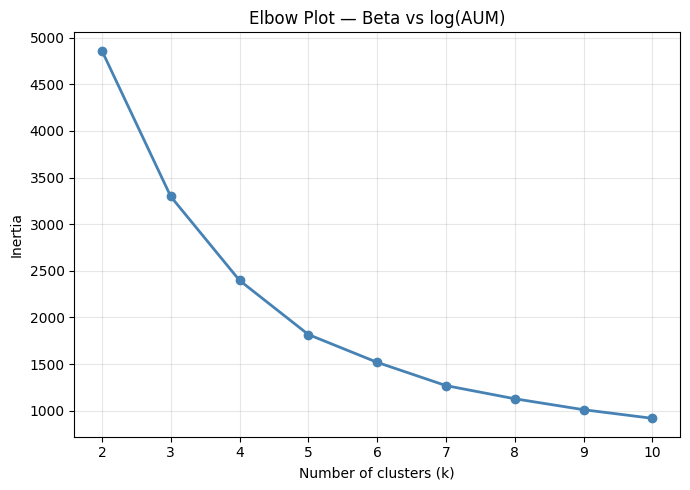

In [325]:
# Elbow plot: how inertia changes as k increases; look for the most pronounced bend

plt.figure(figsize=(7, 5))
plt.plot(elbow_df['k'], elbow_df['inertia'], marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.title('Elbow Plot — Beta vs log(AUM)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

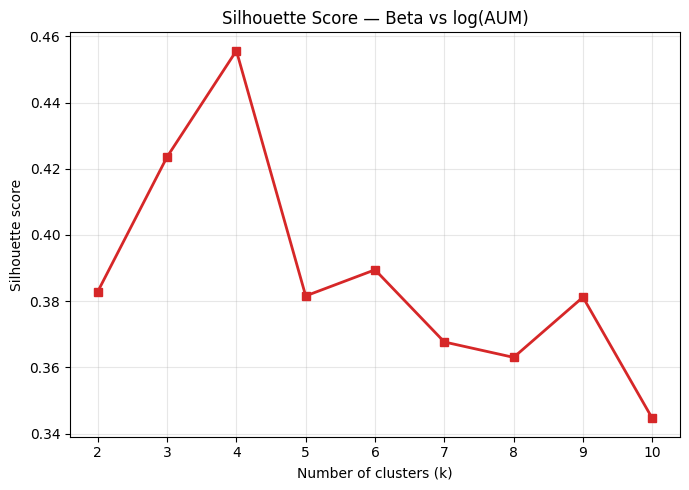

In [326]:
# Silhouette score plot: higher means clearer grouping; look for the peak

plt.figure(figsize=(7, 5))
plt.plot(elbow_df['k'], elbow_df['silhouette_score'], marker='s', linewidth=2, color='tab:red')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(k_values)
plt.title('Silhouette Score — Beta vs log(AUM)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [327]:
# Choose k=4 for the final clustering, because the silhouette score is highest at k=4. In addition, the elbow plot also shows the most pronounced kink at k=4.

chosen_k = 4

kmeans_2d = KMeans(n_clusters=chosen_k, random_state=42, n_init=50)
cluster_data_2d['cluster_beta_aum'] = kmeans_2d.fit_predict(X_scaled)

# Convert the standardized cluster centers back to original values
centers_df = pd.DataFrame(
    scaler_2d.inverse_transform(kmeans_2d.cluster_centers_),
    columns=['flow_perf_beta_winsor', 'avg_log_AUM']
)
centers_df['cluster_beta_aum']  = range(chosen_k)
centers_df['center_AUM_million'] = np.exp(centers_df['avg_log_AUM']) / 1_000_000

# Rank by AUM and beta separately, then combine into a readable label
centers_df['size_rank'] = centers_df['avg_log_AUM'].rank(method='first').astype(int) - 1
centers_df['beta_rank'] = centers_df['flow_perf_beta_winsor'].rank(method='first').astype(int) - 1

size_names = {0: 'Smallest AUM', 1: 'Middle AUM', 2: 'Middle AUM', 3: 'Largest AUM'}
beta_names  = {0: 'Lowest β',    1: 'Middle β',     2: 'Middle β',    3: 'Highest β'}

centers_df['label'] = centers_df['size_rank'].map(size_names) + ' / ' + centers_df['beta_rank'].map(beta_names)

label_map = centers_df.set_index('cluster_beta_aum')['label'].to_dict()
cluster_data_2d['cluster_label'] = cluster_data_2d['cluster_beta_aum'].map(label_map)

In [328]:
# Overall characteristics of each cluster: ETF count, average beta, size, return, significance share

cluster_summary = cluster_data_2d.groupby(['cluster_beta_aum', 'cluster_label'], as_index=False).agg(
    ETF_count         = ('PERMNO',               'count'),
    avg_beta          = ('flow_perf_beta',        'mean'),
    median_beta       = ('flow_perf_beta',        'median'),
    avg_AUM_million   = ('avg_AUM_million',       'mean'),
    median_AUM_million= ('avg_AUM_million',       'median'),
    avg_return        = ('return_mean',            'mean'),
    avg_return_vol    = ('return_std',             'mean'),
    sig_beta_share    = ('beta_significant_5pct',  'mean'),
).sort_values('avg_AUM_million', ascending=False)

cluster_summary.style.format({
    'avg_beta':           '{:.3f}',
    'median_beta':        '{:.3f}',
    'avg_AUM_million':    '{:,.0f}',
    'median_AUM_million': '{:,.0f}',
    'avg_return':         '{:.3%}',
    'avg_return_vol':     '{:.3%}',
    'sig_beta_share':     '{:.1%}',
})

,cluster_beta_aum,cluster_label,ETF_count,avg_beta,median_beta,avg_AUM_million,median_AUM_million,avg_return,avg_return_vol,sig_beta_share
0,0,Largest AUM / Middle β,1454,0.207,0.171,"2,319",454,0.634%,5.352%,24.0%
1,1,Middle AUM / Highest β,178,4.777,2.939,450,123,0.296%,1.585%,25.8%
3,3,Middle AUM / Lowest β,131,-5.677,-2.534,359,98,0.395%,2.153%,15.3%
2,2,Smallest AUM / Middle β,1896,0.183,0.143,35,23,0.346%,6.121%,11.4%


In [329]:
# The 5 largest ETFs in each cluster, to get an intuitive sense of what kind of products each group contains

rep_etfs = cluster_data_2d.sort_values(['cluster_beta_aum', 'avg_AUM_million'], ascending=[True, False]).groupby('cluster_beta_aum').head(5)[['cluster_beta_aum', 'cluster_label', 'TICKER', 'COMNAM', 'flow_perf_beta', 'flow_perf_tstat', 'avg_AUM_million']]

rep_etfs.style.format({
    'flow_perf_beta':  '{:.3f}',
    'flow_perf_tstat': '{:.2f}',
    'avg_AUM_million': '{:,.0f}',
})

,cluster_beta_aum,cluster_label,TICKER,COMNAM,flow_perf_beta,flow_perf_tstat,avg_AUM_million
4668,0,Largest AUM / Middle β,SPY,SPDR S & P 500 E T F TRUST,-0.323,-2.28,"168,684"
43,0,Largest AUM / Middle β,VOO,VANGUARD INDEX FUNDS,0.087,0.37,"129,040"
4683,0,Largest AUM / Middle β,IVV,ISHARES TRUST,-0.014,-0.20,"101,740"
4851,0,Largest AUM / Middle β,VTI,VANGUARD INDEX FUNDS,-0.071,-1.64,"83,829"
4679,0,Largest AUM / Middle β,QQQ,INVESCO QQQ TRUST,-0.084,-0.61,"61,300"
5048,1,Middle AUM / Highest β,SHV,ISHARES TRUST,8.035,0.95,"9,086"
5174,1,Middle AUM / Highest β,BIL,SPDR SERIES TRUST,16.921,1.89,"7,702"
24,1,Middle AUM / Highest β,SCHO,SCHWAB STRATEGIC TRUST,2.203,1.28,"4,368"
598,1,Middle AUM / Highest β,USFR,WISDOMTREE TRUST,5.805,1.11,"4,227"
680,1,Middle AUM / Highest β,FTSM,FIRST TRUST E T F IV,4.728,0.64,"3,660"


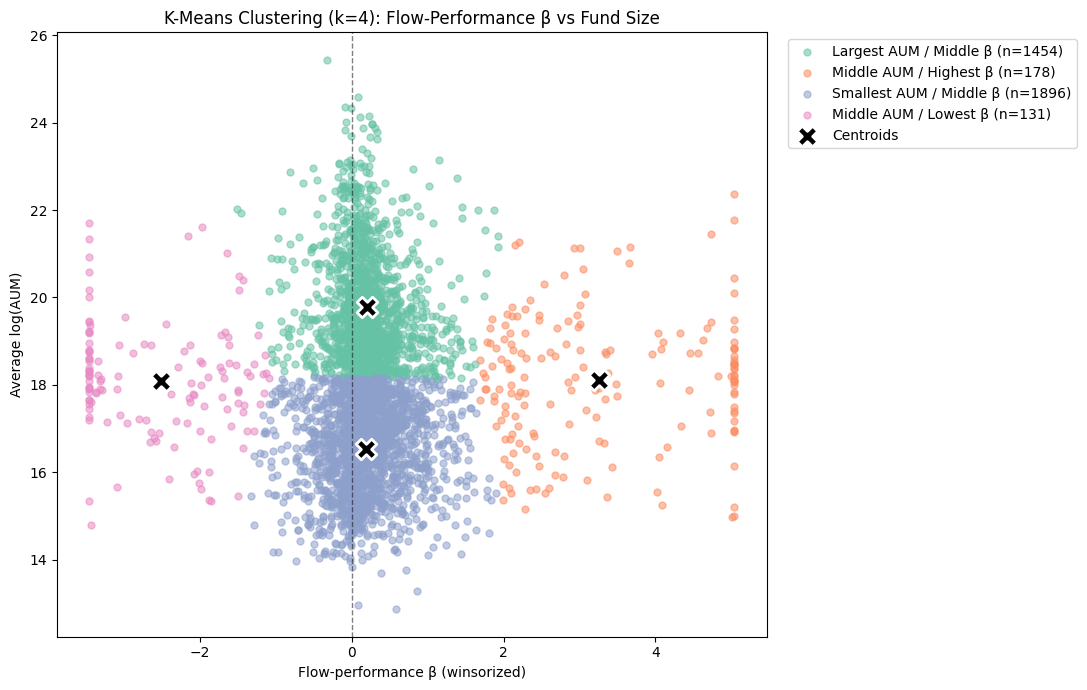

In [330]:
# Plot the clustering results to see how the four groups are distributed in the beta-size coordinate system

palette = sns.color_palette('Set2', n_colors=chosen_k)

plt.figure(figsize=(11, 7))
for k_idx in range(chosen_k):
    sub = cluster_data_2d[cluster_data_2d['cluster_beta_aum'] == k_idx]
    plt.scatter(sub['flow_perf_beta_winsor'], sub['avg_log_AUM'],
                alpha=0.55, s=25, color=palette[k_idx],
                label=f"{label_map[k_idx]} (n={len(sub)})")

# Plot the four cluster centers
plt.scatter(centers_df['flow_perf_beta_winsor'], centers_df['avg_log_AUM'],
            marker='X', s=220, c='black', edgecolor='white', linewidth=2,
            label='Centroids', zorder=5)

plt.axvline(0, color='black', linewidth=1, alpha=0.5, linestyle='--')
plt.xlabel('Flow-performance β (winsorized)')
plt.ylabel('Average log(AUM)')
plt.title(f'K-Means Clustering (k={chosen_k}): Flow-Performance β vs Fund Size')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Merge the cluster labels back into etf_beta_table; sections 6.3/6.4 will use them
etf_beta_table = etf_beta_table.drop(columns=['cluster_beta_aum', 'cluster_label'], errors='ignore')
etf_beta_table = etf_beta_table.merge(
    cluster_data_2d[['PERMNO', 'cluster_beta_aum', 'cluster_label']],
    on='PERMNO', how='left'
)

## 6.3 (flow-performance β) × (market β)

In [331]:
# First estimate the market beta (sensitivity to the broad market) for each ETF, used later to distinguish aggressive from defensive ETFs

mkt_beta_list = []

for permno, group in etf.groupby('PERMNO'):
    g = group.dropna(subset=['RET', 'mkt_ret']).sort_values('date')
    
    # Skip if there is not enough data or the market return has no variation
    if len(g) < 24 or g['mkt_ret'].nunique() < 2:
        mkt_beta_list.append({
            'PERMNO'             : permno,
            'n_obs_mkt_beta'     : len(g),
            'market_beta'        : np.nan,
            'market_beta_tstat'  : np.nan,
            'market_beta_pvalue' : np.nan,
            'market_beta_r2'     : np.nan,
        })
        continue
    
    X   = sm.add_constant(g[['mkt_ret']].astype(float))
    y   = g['RET'].astype(float)
    fit = sm.OLS(y, X).fit(cov_type='HC3')
    
    mkt_beta_list.append({
        'PERMNO'             : permno,
        'n_obs_mkt_beta'     : int(fit.nobs),
        'market_beta'        : fit.params['mkt_ret'],
        'market_beta_tstat'  : fit.tvalues['mkt_ret'],
        'market_beta_pvalue' : fit.pvalues['mkt_ret'],
        'market_beta_r2'     : fit.rsquared,
    })

market_beta_results = pd.DataFrame(mkt_beta_list)

# Drop the old columns first, to avoid errors on repeated runs
mkt_cols = ['n_obs_mkt_beta', 'market_beta', 'market_beta_tstat',
            'market_beta_pvalue', 'market_beta_r2', 'market_beta_winsor']
etf_beta_table = etf_beta_table.drop(columns=mkt_cols, errors='ignore')
etf_beta_table = etf_beta_table.merge(market_beta_results, on='PERMNO', how='left')

# Leveraged/inverse ETFs have wildly large market betas, so winsorize them
etf_beta_table['market_beta_winsor'] = winsorize_series(
    etf_beta_table['market_beta'], lower=0.01, upper=0.01
)

# Take ETFs with data on both dimensions, standardize, then try k=2 to 10
cluster_data_mkt = etf_beta_table.dropna(subset=['flow_perf_beta_winsor', 'market_beta_winsor']).copy()
X_raw_mkt        = cluster_data_mkt[['flow_perf_beta_winsor', 'market_beta_winsor']].astype(float).values

scaler_mkt   = StandardScaler()
X_scaled_mkt = scaler_mkt.fit_transform(X_raw_mkt)

k_values        = list(range(2, 11))
inertia_list    = []
silhouette_list = []

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled_mkt)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled_mkt, labels))

elbow_df_mkt = pd.DataFrame({
    'k'                : k_values,
    'inertia'          : inertia_list,
    'silhouette_score' : silhouette_list,
})

elbow_df_mkt.style.format({'inertia': '{:,.1f}', 'silhouette_score': '{:.3f}'})

,k,inertia,silhouette_score
0,2,"5,059.9",0.568
1,3,"3,788.5",0.609
2,4,"2,902.6",0.588
3,5,"2,058.0",0.383
4,6,"1,493.8",0.441
5,7,"1,158.4",0.442
6,8,989.9,0.438
7,9,859.5,0.358
8,10,745.6,0.362


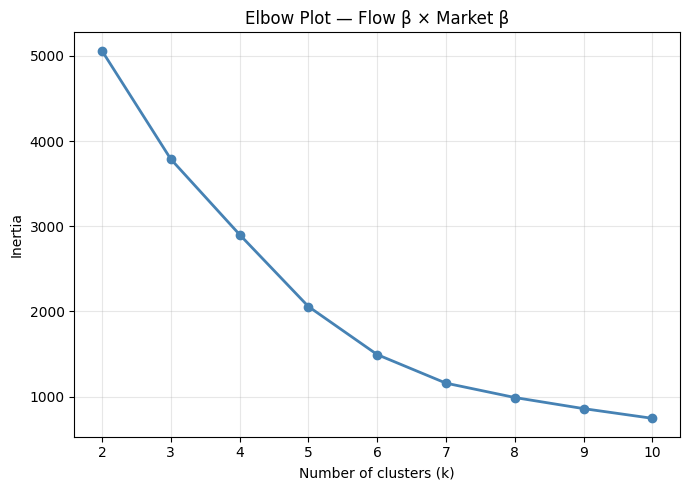

In [332]:
# Elbow plot: see how inertia changes as k increases
plt.figure(figsize=(7, 5))
plt.plot(elbow_df_mkt['k'], elbow_df_mkt['inertia'], marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.title('Elbow Plot — Flow β × Market β')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

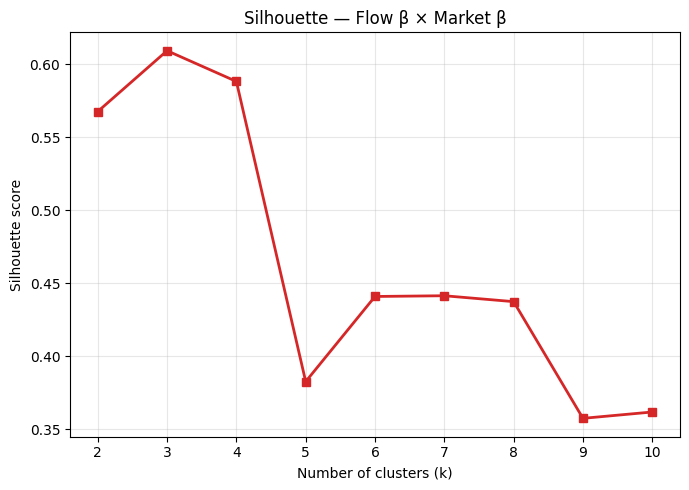

In [333]:
# Silhouette score plot: which k makes the grouping clearest
plt.figure(figsize=(7, 5))
plt.plot(elbow_df_mkt['k'], elbow_df_mkt['silhouette_score'], marker='s', linewidth=2, color='tab:red')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(k_values)
plt.title('Silhouette — Flow β × Market β')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [334]:
# Although in the silhouette score plot k=3 is the highest, for interpretability we still choose k=4 for the final clustering. Moreover, the silhouette scores for k=3 and k=4 are very close.
# Choose k=4 for the final clustering and auto-name clusters based on the relative ranking of the cluster centers

chosen_k_mkt = 4

kmeans_mkt = KMeans(n_clusters=chosen_k_mkt, random_state=42, n_init=50)
cluster_data_mkt['cluster_beta_mktbeta'] = kmeans_mkt.fit_predict(X_scaled_mkt)

# Convert the cluster centers back to original values
centers_mkt = pd.DataFrame(
    scaler_mkt.inverse_transform(kmeans_mkt.cluster_centers_),
    columns=['flow_perf_beta_winsor', 'market_beta_winsor']
)
centers_mkt['cluster_beta_mktbeta'] = range(chosen_k_mkt)

# Auto-name based on the relative ranking of the cluster centers, without using fixed thresholds
centers_mkt['mkt_rank'] = centers_mkt['market_beta_winsor'].rank(method='first').astype(int) - 1
centers_mkt['flow_rank'] = centers_mkt['flow_perf_beta_winsor'].rank(method='first').astype(int) - 1

mkt_names = {
    0: 'Lowest market β',
    1: 'Middle market β',
    2: 'Middle market β',
    3: 'Highest market β',
}

flow_names = {
    0: 'Lowest flow β',
    1: 'Middle flow β',
    2: 'Middle flow β',
    3: 'Highest flow β',
}

centers_mkt['label'] = (
    centers_mkt['mkt_rank'].map(mkt_names)
    + ' / '
    + centers_mkt['flow_rank'].map(flow_names)
)

label_map_mkt = centers_mkt.set_index('cluster_beta_mktbeta')['label'].to_dict()
cluster_data_mkt['cluster_label_mkt'] = cluster_data_mkt['cluster_beta_mktbeta'].map(label_map_mkt)

centers_mkt[['cluster_beta_mktbeta', 'label', 'market_beta_winsor', 'flow_perf_beta_winsor']]\
    .sort_values('market_beta_winsor', ascending=False)\
    .style.format({'market_beta_winsor': '{:.3f}', 'flow_perf_beta_winsor': '{:.3f}'})

,cluster_beta_mktbeta,label,market_beta_winsor,flow_perf_beta_winsor
0,0,Highest market β / Middle flow β,0.909,0.203
3,3,Middle market β / Lowest flow β,0.341,-2.154
2,2,Middle market β / Highest flow β,0.165,3.002
1,1,Lowest market β / Middle flow β,-1.790,0.019


In [335]:
# Summary of each cluster's characteristics: ETF count, flow beta, market beta, size, volatility, significance share

cluster_summary_mkt = cluster_data_mkt.groupby(
    ['cluster_beta_mktbeta', 'cluster_label_mkt'], as_index=False
).agg(
    ETF_count           = ('PERMNO',               'count'),
    avg_flow_beta       = ('flow_perf_beta',        'mean'),
    median_flow_beta    = ('flow_perf_beta',        'median'),
    avg_mkt_beta        = ('market_beta',           'mean'),
    median_mkt_beta     = ('market_beta',           'median'),
    avg_AUM_million     = ('avg_AUM_million',       'mean'),
    avg_return_vol      = ('return_std',            'mean'),
    sig_flow_beta_share = ('beta_significant_5pct', 'mean'),
).sort_values('avg_mkt_beta', ascending=False)

cluster_summary_mkt.style.format({
    'avg_flow_beta'      : '{:.3f}',
    'median_flow_beta'   : '{:.3f}',
    'avg_mkt_beta'       : '{:.3f}',
    'median_mkt_beta'    : '{:.3f}',
    'avg_AUM_million'    : '{:,.0f}',
    'avg_return_vol'     : '{:.3%}',
    'sig_flow_beta_share': '{:.1%}',
})

,cluster_beta_mktbeta,cluster_label_mkt,ETF_count,avg_flow_beta,median_flow_beta,avg_mkt_beta,median_mkt_beta,avg_AUM_million,avg_return_vol,sig_flow_beta_share
0,0,Highest market β / Middle flow β,3162,0.203,0.165,0.915,0.929,"1,056",5.612%,17.0%
3,3,Middle market β / Lowest flow β,174,-4.530,-1.988,0.341,0.348,508,2.214%,12.1%
2,2,Middle market β / Highest flow β,210,4.287,2.573,0.165,0.084,589,1.609%,26.7%
1,1,Lowest market β / Middle flow β,113,0.019,-0.021,-2.094,-1.969,125,13.119%,15.9%


In [336]:
# The 5 largest ETFs in each cluster, to see what kind of products they are

rep_etfs_mkt = cluster_data_mkt\
    .sort_values(['cluster_beta_mktbeta', 'avg_AUM_million'], ascending=[True, False])\
    .groupby('cluster_beta_mktbeta')\
    .head(5)\
    [['cluster_beta_mktbeta', 'cluster_label_mkt', 'TICKER', 'COMNAM',
      'flow_perf_beta', 'market_beta', 'avg_AUM_million']]

rep_etfs_mkt.style.format({
    'flow_perf_beta' : '{:.3f}',
    'market_beta'    : '{:.3f}',
    'avg_AUM_million': '{:,.0f}',
})

,cluster_beta_mktbeta,cluster_label_mkt,TICKER,COMNAM,flow_perf_beta,market_beta,avg_AUM_million
4668,0,Highest market β / Middle flow β,SPY,SPDR S & P 500 E T F TRUST,-0.323,0.996,"168,684"
43,0,Highest market β / Middle flow β,VOO,VANGUARD INDEX FUNDS,0.087,0.999,"129,040"
4683,0,Highest market β / Middle flow β,IVV,ISHARES TRUST,-0.014,0.995,"101,740"
4851,0,Highest market β / Middle flow β,VTI,VANGUARD INDEX FUNDS,-0.071,1.020,"83,829"
4679,0,Highest market β / Middle flow β,QQQ,INVESCO QQQ TRUST,-0.084,1.274,"61,300"
4922,1,Lowest market β / Middle flow β,SH,PROSHARES TRUST,0.141,-0.942,"1,625"
4957,1,Lowest market β / Middle flow β,SDS,PROSHARES TRUST,0.022,-1.799,"1,549"
5624,1,Lowest market β / Middle flow β,SQQQ,PROSHARES TRUST,0.107,-2.859,"1,180"
5502,1,Lowest market β / Middle flow β,SPXU,PROSHARES TRUST,0.337,-2.662,609
4956,1,Lowest market β / Middle flow β,QID,PROSHARES TRUST,-0.369,-1.954,545


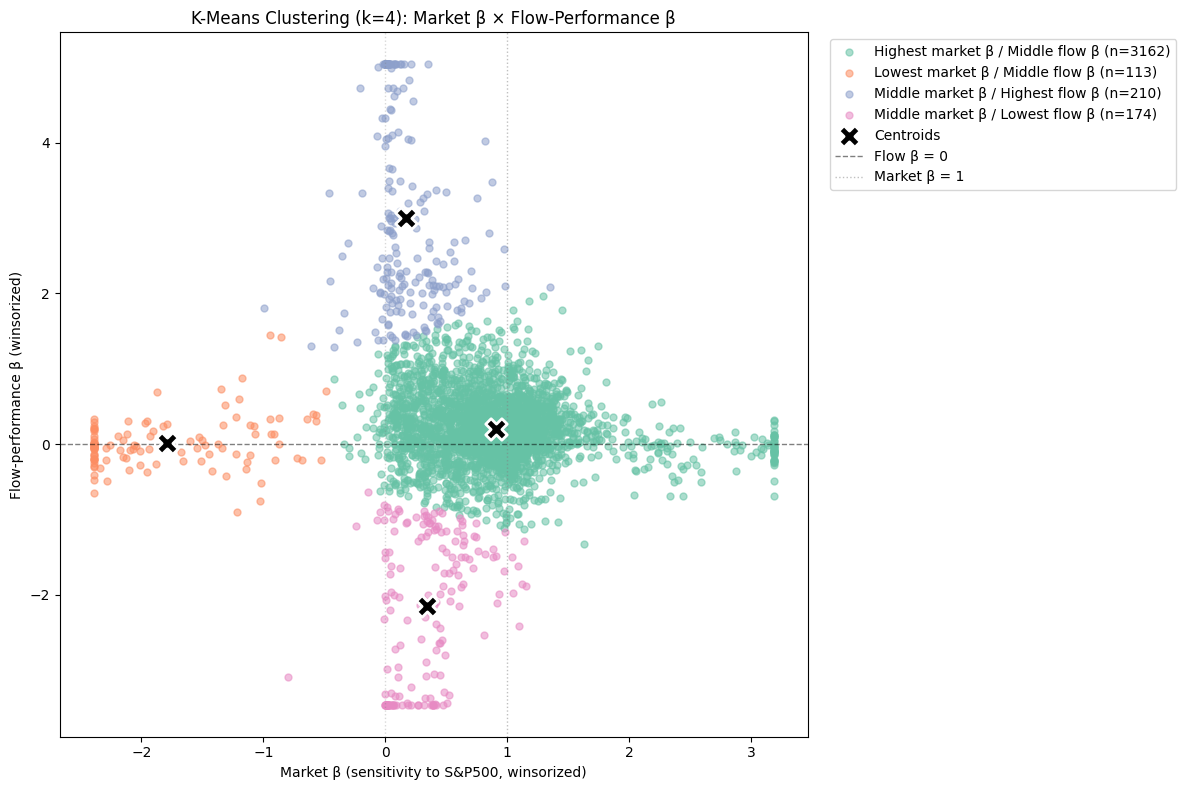

In [337]:
# Four-quadrant scatter plot: market beta on the x-axis, flow beta on the y-axis

palette = sns.color_palette('Set2', n_colors=chosen_k_mkt)

plt.figure(figsize=(12, 8))
for k_idx in range(chosen_k_mkt):
    sub = cluster_data_mkt[cluster_data_mkt['cluster_beta_mktbeta'] == k_idx]
    plt.scatter(sub['market_beta_winsor'], sub['flow_perf_beta_winsor'],
                alpha=0.55, s=25, color=palette[k_idx],
                label=f"{label_map_mkt[k_idx]} (n={len(sub)})")

# Cluster centers
plt.scatter(centers_mkt['market_beta_winsor'], centers_mkt['flow_perf_beta_winsor'],
            marker='X', s=240, c='black', edgecolor='white', linewidth=2,
            label='Centroids', zorder=5)

# Four-quadrant reference lines
plt.axhline(0, color='black', linewidth=1, alpha=0.5, linestyle='--', label='Flow β = 0')
plt.axvline(1, color='gray',  linewidth=1, alpha=0.5, linestyle=':',  label='Market β = 1')
plt.axvline(0, color='gray',  linewidth=1, alpha=0.3, linestyle=':')

# Text annotations for the four quadrants
plt.xlabel('Market β (sensitivity to S&P500, winsorized)')
plt.ylabel('Flow-performance β (winsorized)')
plt.title(f'K-Means Clustering (k={chosen_k_mkt}): Market β × Flow-Performance β')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Merge the cluster labels back into etf_beta_table; section 6.4 will use them
etf_beta_table = etf_beta_table.drop(columns=['cluster_beta_mktbeta', 'cluster_label_mkt'], errors='ignore')
etf_beta_table = etf_beta_table.merge(
    cluster_data_mkt[['PERMNO', 'cluster_beta_mktbeta', 'cluster_label_mkt']],
    on='PERMNO', how='left'
)

## 6.4 Analysis by fund type

In [338]:
# Classify each ETF based on its name and ticker
# Note: check leveraged/inverse first, otherwise an inverse ETF with "TECHNOLOGY" in its name would be misclassified into the technology sector

from scipy.stats import f_oneway, kruskal

def classify_fund_type(row):
    name   = str(row['COMNAM']).upper()
    ticker = str(row['TICKER']).upper()
    text   = f"{ticker} {name}"

    if any(k in text for k in ['LEVERAGED', 'INVERSE', 'ULTRA', 'ULTRASHORT', 'ULTRA SHORT',
                                '2X', '3X', '-1X', 'BEAR', 'DAILY SHORT',
                                'DAILY 2', 'DAILY 3', 'PROSHARES ULTRA']):
        return 'Leveraged/Inverse'

    if any(k in text for k in ['TREASURY', 'TREAS', 'T-BILL', 'BOND', 'FIXED INCOME',
                                'MUNICIPAL', 'MUNI', 'CORPORATE BOND', 'CORP BOND',
                                'HIGH YIELD', 'CREDIT', 'MORTGAGE', 'FLOATING RATE',
                                'LOAN', 'AGGREGATE', 'TIPS', 'INFLATION-PROTECTED']):
        return 'Bond / Fixed Income'

    if any(k in text for k in ['GOLD', 'SILVER', 'OIL', 'NATURAL GAS', 'COMMODITY', 'COMMODITIES',
                                'METAL', 'PRECIOUS', 'COPPER', 'PLATINUM', 'PALLADIUM',
                                'ENERGY FUND', 'AGRICULTURE']):
        return 'Commodity'

    if any(k in text for k in ['REIT', 'REAL ESTATE']):
        return 'Real Estate'

    if any(k in text for k in ['EMERGING', 'DEVELOPED', 'INTERNATIONAL', 'GLOBAL EX',
                                'EX-US', 'EX US', 'EAFE', 'CHINA', 'JAPAN', 'EUROPE',
                                'ASIA', 'LATIN', 'BRAZIL', 'INDIA', 'KOREA', 'TAIWAN',
                                'MEXICO', 'CANADA', 'FTSE', 'MSCI EAFE', 'WORLD EX']):
        return 'International / EM Equity'

    if any(k in text for k in ['SECTOR', 'TECHNOLOGY', 'SEMICONDUCTOR', 'HEALTH', 'BIOTECH',
                                'FINANCIAL', 'ENERGY', 'UTILITY', 'UTILITIES', 'INDUSTRIAL',
                                'MATERIALS', 'CONSUMER', 'COMMUNICATION', 'CYBER',
                                'ROBOT', 'SOLAR', 'CLEAN ENERGY', 'AEROSPACE', 'INFRASTRUCTURE',
                                'INNOVATION', 'GENOMIC', 'AI ', 'ARTIFICIAL']):
        return 'Sector / Thematic Equity'

    if any(k in text for k in ['CURRENCY', 'DOLLAR', 'EURO', 'YEN', 'BITCOIN', 'CRYPTO', 'ETHEREUM']):
        return 'Currency / Crypto'

    if any(k in text for k in ['S&P', 'NASDAQ', 'RUSSELL', 'TOTAL STOCK', 'LARGE CAP', 'MID CAP',
                                'SMALL CAP', 'VALUE', 'GROWTH', 'DIVIDEND', 'EQUITY',
                                'STOCK', 'INDEX FUND', 'ETF TRUST']):
        return 'Broad Equity'

    return 'Other / Mixed'


etf_beta_table['fund_type'] = etf_beta_table.apply(classify_fund_type, axis=1)

# Check how many ETFs fell into each category
etf_beta_table['fund_type'].value_counts().to_frame('ETF_count')

,ETF_count
fund_type,
Other / Mixed,5070
Broad Equity,377
Commodity,78
Sector / Thematic Equity,67
Bond / Fixed Income,36
International / EM Equity,35
Currency / Crypto,23
Real Estate,1
Leveraged/Inverse,1


In [339]:
# Compute beta statistics for each fund type to see which type's investors are most prone to chasing returns

etf_clean = etf_beta_table.dropna(subset=['flow_perf_beta_winsor', 'fund_type'])

fund_type_stats = etf_clean.groupby('fund_type', as_index=False).agg(
    n_etf              = ('PERMNO',               'count'),
    mean_beta          = ('flow_perf_beta_winsor', 'mean'),
    median_beta        = ('flow_perf_beta_winsor', 'median'),
    std_beta           = ('flow_perf_beta_winsor', 'std'),
    sig_share          = ('beta_significant_5pct', 'mean'),
    mean_AUM_million   = ('avg_AUM_million',       'mean'),
    median_AUM_million = ('avg_AUM_million',       'median'),
)

# Compute the quantiles separately and merge them in, which is clearer than writing a lambda inside agg
q25 = etf_clean.groupby('fund_type')['flow_perf_beta_winsor'].quantile(0.25).rename('q25_beta').reset_index()
q75 = etf_clean.groupby('fund_type')['flow_perf_beta_winsor'].quantile(0.75).rename('q75_beta').reset_index()

fund_type_stats = fund_type_stats.merge(q25, on='fund_type').merge(q75, on='fund_type')
fund_type_stats = fund_type_stats.sort_values('mean_beta', ascending=False)

fund_type_stats[['fund_type', 'n_etf', 'mean_beta', 'median_beta', 'std_beta',
                  'q25_beta', 'q75_beta', 'sig_share', 'mean_AUM_million', 'median_AUM_million']]\
    .style.format({
        'mean_beta':          '{:+.3f}',
        'median_beta':        '{:+.3f}',
        'std_beta':           '{:.3f}',
        'q25_beta':           '{:+.3f}',
        'q75_beta':           '{:+.3f}',
        'sig_share':          '{:.1%}',
        'mean_AUM_million':   '{:,.0f}',
        'median_AUM_million': '{:,.0f}',
    }).background_gradient(subset=['mean_beta', 'median_beta'], cmap='RdYlGn')

,fund_type,n_etf,mean_beta,median_beta,std_beta,q25_beta,q75_beta,sig_share,mean_AUM_million,median_AUM_million
3,Currency / Crypto,10,+0.741,+0.659,0.832,+0.596,+0.921,40.0%,210,167
4,International / EM Equity,20,+0.435,+0.398,0.616,-0.021,+0.746,10.0%,42,11
5,Other / Mixed,3335,+0.257,+0.167,1.004,-0.062,+0.469,17.5%,819,81
7,Sector / Thematic Equity,34,+0.231,+0.107,0.629,-0.031,+0.242,14.7%,"4,179","2,448"
6,Real Estate,1,+0.229,+0.229,nan,+0.229,+0.229,0.0%,22,22
1,Broad Equity,184,+0.115,+0.102,1.005,-0.147,+0.472,13.6%,"2,888",54
2,Commodity,48,+0.082,+0.118,0.778,-0.123,+0.306,18.8%,"1,464",194
0,Bond / Fixed Income,27,-0.219,+0.006,1.774,-0.292,+0.619,18.5%,"3,240",73


In [340]:
# Use ANOVA and Kruskal-Wallis tests: is the difference in mean beta across fund types statistically significant
# Keep only categories with >=10 ETFs, since small groups have unreliable means; Kruskal does not require normality and is more robust than ANOVA

valid_types = fund_type_stats.loc[fund_type_stats['n_etf'] >= 10, 'fund_type'].tolist()

groups = [
    etf_beta_table.loc[etf_beta_table['fund_type'] == t, 'flow_perf_beta_winsor'].dropna().values
    for t in valid_types
]

anova_stat,   anova_p   = f_oneway(*groups)
kruskal_stat, kruskal_p = kruskal(*groups)

pd.Series({
    'ANOVA F-statistic':       round(anova_stat,   3),
    'ANOVA p-value':           round(anova_p,      4),
    'Kruskal-Wallis H-statistic': round(kruskal_stat, 3),
    'Kruskal-Wallis p-value':  round(kruskal_p,    4),
}).to_frame('Test result')

,Test result
ANOVA F-statistic,2.2860
ANOVA p-value,0.0332
Kruskal-Wallis H-statistic,16.5590
Kruskal-Wallis p-value,0.0110


In [341]:
# See which fund type has the highest beta and which has the lowest

valid_stats = fund_type_stats[fund_type_stats['fund_type'].isin(valid_types)].reset_index(drop=True)
top_type    = valid_stats.iloc[0]
bot_type    = valid_stats.iloc[-1]

# Number of fund types included in the test
print(len(valid_types))
# Fund type with the highest beta
print(top_type['fund_type'])
print(round(top_type['mean_beta'], 3))
# Fund type with the lowest beta
print(bot_type['fund_type'])
print(round(bot_type['mean_beta'], 3))

7
Currency / Crypto
0.741
Bond / Fixed Income
-0.219


In [342]:
# The p-values of the two tests, and whether the null hypothesis of "equal beta across types" is rejected

# ANOVA p-value
print(round(anova_p, 4))
# Kruskal-Wallis p-value
print(round(kruskal_p, 4))
# Whether it is significant
if min(anova_p, kruskal_p) < 0.05:
    print('Yes')
else:
    print('No')

# Conclusion: there is a significant difference in flow-performance beta across fund types.

0.0332
0.011
Yes


## 6.5 Summary

This section attempts to group ETFs based on their flow performance sensitivity β. Here, β can be understood as: whether the inflow of funds in the current period will increase when the previous period's returns of ETF improve, and to what extent the increase will be.

Firstly, we separately estimate this beta value for each ETF with a sample period of no less than 24 months. Out of 5688 ETFs, a total of 3659 were successfully estimated, with approximately 17% of ETFs being statistically significant. It is worth noting that the vast majority of significant β values are positive, with only a very small number being negative, indicating that investors generally tend to invest their funds in ETFs that have performed well in the near future, that is, there is a certain phenomenon of "chasing the rise".

Subsequently, we combined the fund flow sensitivity β with the fund size (AUM) and grouped them using K-means clustering. It was found that the beta of most ETFs is concentrated around 0, indicating that the flow of funds is not particularly sensitive to historical returns. Only a few ETFs exhibit very strong chasing or reverse behavior, and these extreme situations mainly occur in small and medium-sized funds.

After further clustering based on market beta (the sensitivity of funds to market fluctuations), the subjects in the sample are ordinary ETFs with high market beta and near zero sensitivity to cash flow; In addition, there are a small number of special funds with strong reverse trading or high volatility characteristics.

Finally, comparing by fund category, it was found that there are significant differences in the sensitivity of fund flow among different types of ETFs. Among them, Currency/Crypto ETFs have the strongest tendency to chase after gains, followed by International/EM ETFs, while Bond/Fixed Income ETFs are the weakest and even exhibit some reverse characteristics. The statistical test results also indicate that these differences are significant.

Overall, the capital flow of most ETFs is not sensitive to past returns, but in funds with significant relationships, funds typically exhibit a "performance chasing" characteristic. At the same time, price chasing behavior is more concentrated in small and medium-sized funds, and there are significant differences in investor behavior patterns among different types of ETFs.

# 7. Task 3: Sensitivity analysis of ETF returns to market returns

In [343]:
# Estimate each ETF's market beta using a 36-month rolling window, then aggregate monthly into 5 different averaging methods

ROLLING_WINDOW   = 36
MIN_OBS_ROLLING  = 24

rolling_data = etf[['PERMNO', 'TICKER', 'COMNAM', 'date', 'RET', 'mkt_ret', 'AUM']]\
    .dropna(subset=['RET', 'mkt_ret'])\
    .sort_values(['PERMNO', 'date'])\
    .reset_index(drop=True)

# Use the closed-form covariance/variance formula to compute rolling beta, which is much faster than running OLS each time
beta_list = []
for permno, group in rolling_data.groupby('PERMNO'):
    g      = group.sort_values('date').copy()
    cov_rm = g['RET'].rolling(ROLLING_WINDOW, min_periods=MIN_OBS_ROLLING).cov(g['mkt_ret'])
    var_m  = g['mkt_ret'].rolling(ROLLING_WINDOW, min_periods=MIN_OBS_ROLLING).var()
    g['rolling_market_beta'] = cov_rm / var_m
    beta_list.append(g)

rolling_data = pd.concat(beta_list).reset_index(drop=True)

# Winsorize cross-sectionally for each month, skipping early months with fewer than 10 samples
def winsorize_cross_section(s, lower=0.01, upper=0.01, min_n=10):
    valid = s.dropna()
    if len(valid) < min_n:
        return s
    lo = valid.quantile(lower)
    hi = valid.quantile(1 - upper)
    return s.clip(lower=lo, upper=hi)

rolling_data['rolling_market_beta_winsor'] = rolling_data.groupby('date')['rolling_market_beta']\
    .transform(winsorize_cross_section)

rolling_ready = rolling_data.dropna(subset=['rolling_market_beta']).copy()

# Compute 5 aggregation methods by month
# Equal-weight mean, winsorized equal-weight mean, and median computed directly with groupby
eq_mean   = rolling_ready.groupby('date')['rolling_market_beta'].mean().rename('equal_mean')
eq_winsor = rolling_ready.groupby('date')['rolling_market_beta_winsor'].mean().rename('equal_mean_winsor')
med       = rolling_ready.groupby('date')['rolling_market_beta'].median().rename('median')
n_etfs    = rolling_ready.groupby('date')['PERMNO'].nunique().rename('num_etfs')

# AUM-weighted mean: computed separately for each month
aum_rows = []
for date, g in rolling_ready.groupby('date'):
    valid = g.dropna(subset=['rolling_market_beta_winsor', 'AUM'])
    valid = valid[valid['AUM'] > 0]
    if len(valid) == 0:
        aum_rows.append({'date': date, 'aum_weighted': np.nan})
    else:
        aum_rows.append({'date': date, 'aum_weighted': np.average(valid['rolling_market_beta_winsor'], weights=valid['AUM'])})
aum_w = pd.DataFrame(aum_rows).set_index('date')['aum_weighted']

# 5%/95% trimmed mean: remove the most extreme 10% then average
trimmed_rows = []
for date, g in rolling_ready.groupby('date'):
    s = g['rolling_market_beta_winsor'].dropna()
    if len(s) == 0:
        trimmed_rows.append({'date': date, 'trimmed_5_95': np.nan})
    else:
        lo, hi = s.quantile(0.05), s.quantile(0.95)
        trimmed_rows.append({'date': date, 'trimmed_5_95': s[(s >= lo) & (s <= hi)].mean()})
trimmed = pd.DataFrame(trimmed_rows).set_index('date')['trimmed_5_95']

avg_beta_ts = pd.concat([eq_mean, eq_winsor, med, aum_w, trimmed, n_etfs], axis=1).reset_index()

# Basic statistics: number of observations, number of ETFs, and time range
print(len(rolling_ready))
print(rolling_ready['PERMNO'].nunique())
print(rolling_ready['date'].min().date(), '~', rolling_ready['date'].max().date())

272046
3711
2001-12-31 ~ 2024-12-31


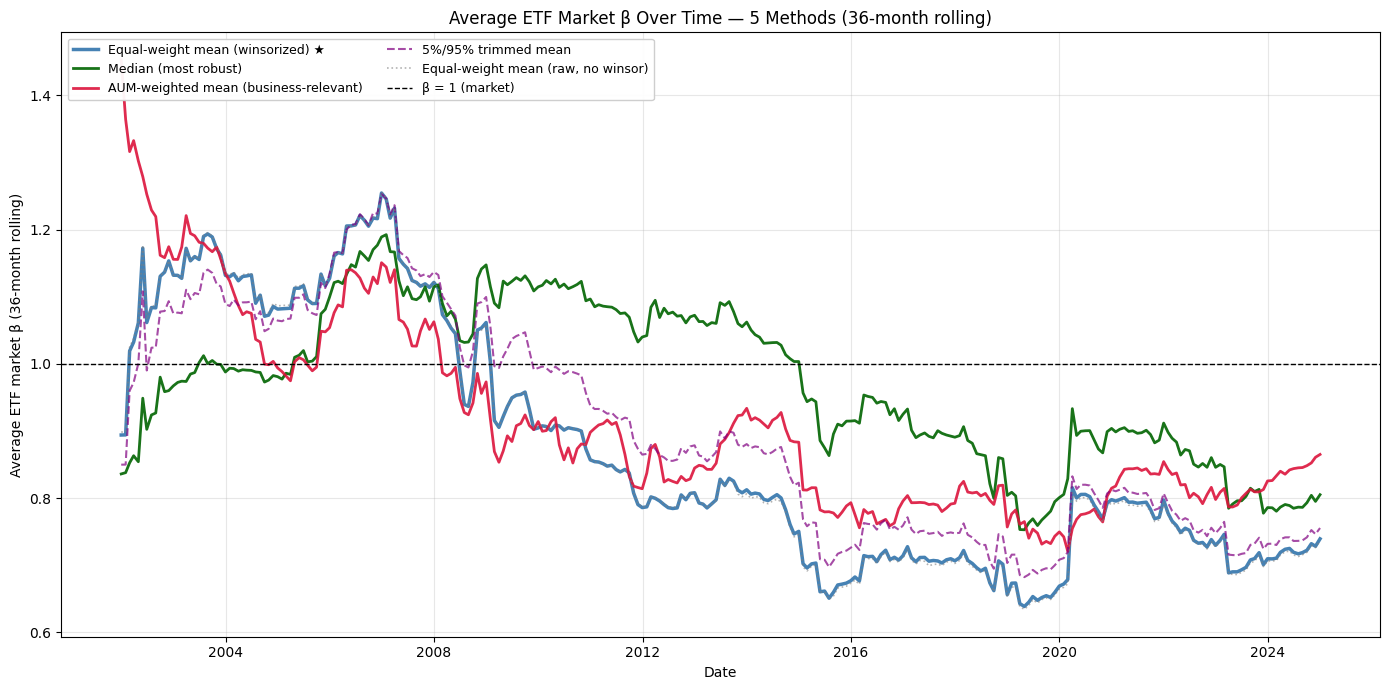

In [344]:
# Plot the time series of all 5 averaging methods in one figure, with ETF count on the right axis

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(avg_beta_ts['date'], avg_beta_ts['equal_mean_winsor'],
         label='Equal-weight mean (winsorized) ★', linewidth=2.5, color='steelblue')
ax1.plot(avg_beta_ts['date'], avg_beta_ts['median'],
         label='Median (most robust)', linewidth=2, color='darkgreen', alpha=0.9)
ax1.plot(avg_beta_ts['date'], avg_beta_ts['aum_weighted'],
         label='AUM-weighted mean (business-relevant)', linewidth=2, color='crimson', alpha=0.9)
ax1.plot(avg_beta_ts['date'], avg_beta_ts['trimmed_5_95'],
         label='5%/95% trimmed mean', linewidth=1.5, color='purple', linestyle='--', alpha=0.7)
ax1.plot(avg_beta_ts['date'], avg_beta_ts['equal_mean'],
         label='Equal-weight mean (raw, no winsor)', linewidth=1.2, color='gray', linestyle=':', alpha=0.6)
ax1.axhline(1, color='black', linestyle='--', linewidth=1, label='β = 1 (market)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average ETF market β (36-month rolling)')

ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)


ax1.set_title('Average ETF Market β Over Time — 5 Methods (36-month rolling)')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison of the 5 methods:
# equal_mean (raw): includes extreme betas, the least robust, used only for reference
# equal_mean_winsor: equal-weight after cross-sectional 1%/99% winsorizing, recommended for the main text
# median: completely unaffected by extreme values, but underestimates the mainstream market level
# aum_weighted: weighted by AUM, reflects the real dollar flow, with the strongest business meaning
# trimmed_5_95: equal-weight after dropping the most extreme 10%, between winsor and median

In [345]:
# Aggregate the average beta by year to see the long-term trend

avg_beta_ts['year'] = avg_beta_ts['date'].dt.year

annual_beta = avg_beta_ts.groupby('year', as_index=False).agg(
    equal_mean_winsor = ('equal_mean_winsor', 'mean'),
    median            = ('median',            'mean'),
    aum_weighted      = ('aum_weighted',      'mean'),
    avg_num_etfs      = ('num_etfs',          'mean'),
)

annual_beta.style.format({
    'equal_mean_winsor': '{:.3f}',
    'median':            '{:.3f}',
    'aum_weighted':      '{:.3f}',
    'avg_num_etfs':      '{:,.0f}',
})

,year,equal_mean_winsor,median,aum_weighted,avg_num_etfs
0,2001,0.894,0.836,1.453,32
1,2002,1.080,0.915,1.245,66
2,2003,1.161,0.991,1.175,102
3,2004,1.107,0.986,1.051,117
4,2005,1.103,1.022,1.008,129
5,2006,1.203,1.151,1.117,157
6,2007,1.155,1.123,1.072,191
7,2008,1.029,1.082,0.970,287
8,2009,0.936,1.115,0.896,491
9,2010,0.898,1.115,0.886,616


In [346]:
# Run a linear trend regression on the average beta to see whether the overall direction is upward or downward

import statsmodels.api as sm

trend_df           = avg_beta_ts.dropna(subset=['equal_mean_winsor']).copy().reset_index(drop=True)
trend_df['time_idx'] = np.arange(len(trend_df))

X = sm.add_constant(trend_df[['time_idx']].astype(float))
y = trend_df['equal_mean_winsor'].astype(float)
trend_fit = sm.OLS(y, X).fit(cov_type='HC3')

monthly_slope = trend_fit.params['time_idx']
annual_slope  = monthly_slope * 12
trend_p       = trend_fit.pvalues['time_idx']
direction     = 'Upward' if annual_slope > 0 else 'Downward'
sig_word      = 'Significant' if trend_p < 0.05 else 'Not significant'

trend_df['fitted'] = trend_fit.predict(X)

# Monthly slope, t-value, p-value
print(round(monthly_slope, 5))
print(round(trend_fit.tvalues['time_idx'], 2))
print(round(trend_p, 4))
# Annualized slope, direction, significance
print(round(annual_slope, 4))
print(direction)
print(sig_word)
# R²
print(round(trend_fit.rsquared, 4))

-0.00193
-27.39
0.0
-0.0231
Downward
Significant
0.7386


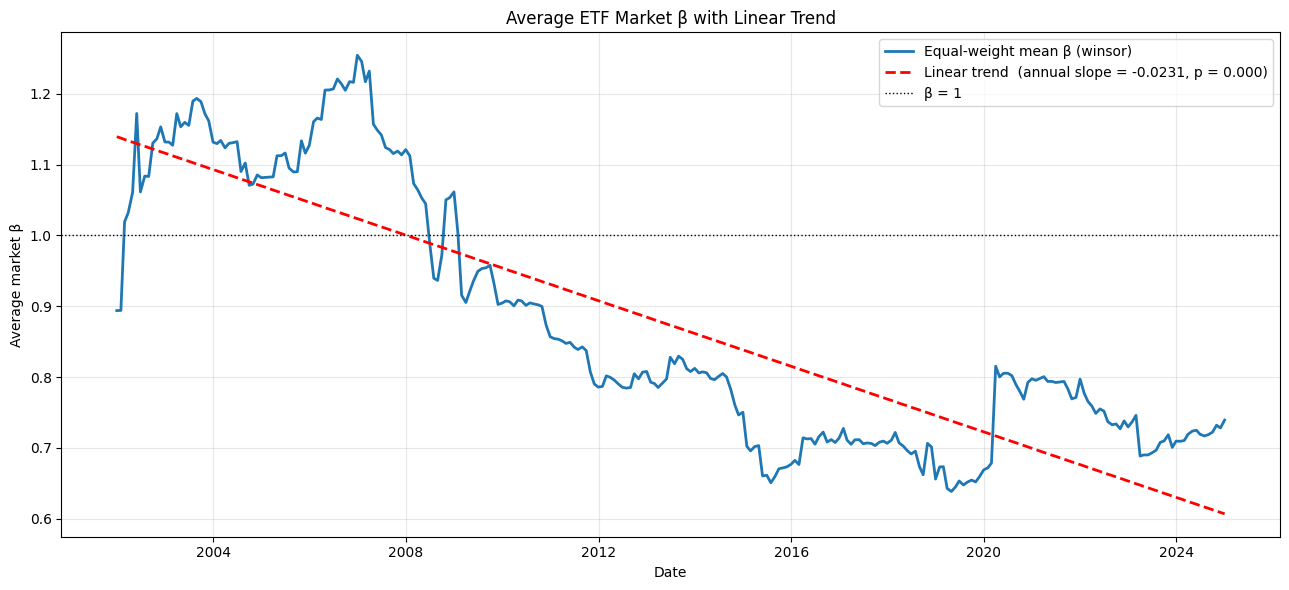

In [347]:
# Plot the average beta together with the linear trend line

plt.figure(figsize=(13, 6))
plt.plot(trend_df['date'], trend_df['equal_mean_winsor'],
         label='Equal-weight mean β (winsor)', linewidth=2)
plt.plot(trend_df['date'], trend_df['fitted'],
         label=f'Linear trend  (annual slope = {annual_slope:+.4f}, p = {trend_p:.3f})',
         linestyle='--', linewidth=2, color='red')
plt.axhline(1, color='black', linestyle=':', linewidth=1, label='β = 1')
plt.xlabel('Date')
plt.ylabel('Average market β')
plt.title('Average ETF Market β with Linear Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [348]:
# Split ETFs into four cohorts by launch year to see whether ETFs launched in different periods differ in market beta

launch_info = etf.groupby('PERMNO', as_index=False).agg(launch_date=('date', 'min'))
launch_info['launch_year'] = launch_info['launch_date'].dt.year

def assign_cohort(year):
    if year <= 2007:
        return 'Launched ≤2007'
    elif year <= 2013:
        return 'Launched 2008-2013'
    elif year <= 2019:
        return 'Launched 2014-2019'
    else:
        return 'Launched 2020-Latest'

launch_info['launch_cohort'] = launch_info['launch_year'].apply(assign_cohort)

cohort_beta = launch_info.merge(
    etf_beta_table[['PERMNO', 'market_beta', 'market_beta_winsor',
                    'market_beta_pvalue', 'fund_type', 'avg_AUM_million']],
    on='PERMNO', how='left'
)

# Compute the significance share separately to avoid writing a lambda inside agg
cohort_beta['is_sig'] = cohort_beta['market_beta_pvalue'] < 0.05

cohort_order = ['Launched ≤2007', 'Launched 2008-2013', 'Launched 2014-2019', 'Launched 2020-Latest']

cohort_summary = cohort_beta.dropna(subset=['market_beta_winsor'])\
    .groupby('launch_cohort', as_index=False).agg(
        ETF_count          = ('PERMNO',              'count'),
        avg_market_beta    = ('market_beta_winsor',  'mean'),
        median_market_beta = ('market_beta',         'median'),
        avg_AUM_million    = ('avg_AUM_million',     'mean'),
        sig_share          = ('is_sig',              'mean'),
    )

cohort_summary['launch_cohort'] = pd.Categorical(
    cohort_summary['launch_cohort'], categories=cohort_order, ordered=True
)
cohort_summary = cohort_summary.sort_values('launch_cohort')

cohort_summary.style.format({
    'avg_market_beta':    '{:.3f}',
    'median_market_beta': '{:.3f}',
    'avg_AUM_million':    '{:,.0f}',
    'sig_share':          '{:.1%}',
})

,launch_cohort,ETF_count,avg_market_beta,median_market_beta,avg_AUM_million,sig_share
3,Launched ≤2007,587,0.855,1.039,"3,191",96.4%
0,Launched 2008-2013,825,0.694,0.838,"1,089",91.2%
1,Launched 2014-2019,1262,0.742,0.814,410,93.2%
2,Launched 2020-Latest,1037,0.770,0.807,275,92.9%


In [349]:
# The fund-type composition of each cohort, to see what kinds of products ETFs launched in different periods are

launch_type_dist = pd.crosstab(
    cohort_beta['launch_cohort'],
    cohort_beta['fund_type'],
    normalize='index'
).reindex(cohort_order)

launch_type_dist.style.format('{:.1%}')

fund_type,Bond / Fixed Income,Broad Equity,Commodity,Currency / Crypto,International / EM Equity,Leveraged/Inverse,Other / Mixed,Real Estate,Sector / Thematic Equity
launch_cohort,,,,,,,,,
Launched ≤2007,0.6%,4.6%,0.6%,1.2%,0.3%,0.0%,86.1%,0.0%,6.6%
Launched 2008-2013,0.2%,4.6%,0.9%,0.1%,1.8%,0.1%,92.2%,0.0%,0.1%
Launched 2014-2019,0.1%,7.5%,2.1%,0.1%,0.3%,0.0%,89.6%,0.0%,0.5%
Launched 2020-Latest,1.1%,7.4%,1.3%,0.5%,0.5%,0.0%,88.5%,0.0%,0.6%


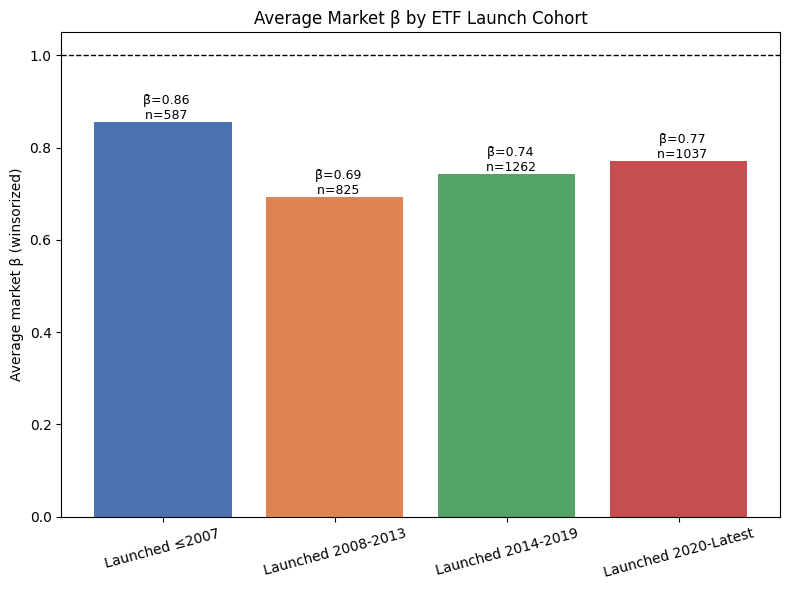

In [350]:
# Bar chart: the average market beta of each cohort; do earlier-launched ETFs have higher betas?

plt.figure(figsize=(8, 6))
plt.bar(cohort_summary['launch_cohort'].astype(str), cohort_summary['avg_market_beta'],
        color=['#4c72b0', '#dd8452', '#55a467', '#c44e52'])
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.ylabel('Average market β (winsorized)')
plt.title('Average Market β by ETF Launch Cohort')
plt.xticks(rotation=15)
for i, (b, n) in enumerate(zip(cohort_summary['avg_market_beta'], cohort_summary['ETF_count'])):
    plt.text(i, b, f"  β̄={b:.2f}\n  n={n}", ha='center',
             va='bottom' if b >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

In [351]:
# Summary of conclusions: the latest beta value, the long-term trend, and the comparison of old vs new cohorts

latest     = avg_beta_ts.iloc[-1]
latest_c   = cohort_summary[cohort_summary['launch_cohort'] == 'Launched 2020-Latest'].iloc[0]
earliest_c = cohort_summary[cohort_summary['launch_cohort'] == 'Launched ≤2007'].iloc[0]
diff       = latest_c['avg_market_beta'] - earliest_c['avg_market_beta']

In [352]:
# Latest month
print(latest['date'].strftime('%Y-%m'))

2024-12


In [353]:
# Latest beta from each method
print(round(latest['equal_mean_winsor'], 3))
print(round(latest['aum_weighted'],      3))
print(round(latest['median'],            3))
print(round(latest['trimmed_5_95'],      3))
print(int(latest['num_etfs']))

0.739
0.865
0.805
0.755
2580


In [354]:
# Long-term trend: annualized slope, direction, significance
print(round(annual_slope, 4))
print(direction)
print(round(trend_p, 3))

-0.0231
Downward
0.0


In [355]:
# Gap in beta between new and old cohorts
print(round(latest_c['avg_market_beta'],   3))
print(round(earliest_c['avg_market_beta'], 3))
print(round(diff, 3))

0.77
0.855
-0.085


## Summary

This section studies the sensitivity of ETFs to overall market fluctuations (market β) and how this sensitivity changes over time. Market β can be simply understood as: how much the ETF will fluctuate on average with a 1% increase or decrease in the market.

The results show that the average market beta of ETFs has shown a significant downward trend over the past two decades. In the early 2000s, the beta of most ETFs was between 1.1-1.2, indicating that their volatility was basically synchronized with the market or even slightly higher; But it continued to decline thereafter, and by the end of 2024, the average β under different statistical calibers had been below 1. This means that the overall sensitivity of ETFs to market fluctuations is significantly weaker than in the early days.

Similar patterns can also be observed when grouped by establishment time. The earliest established ETFs have the highest average market beta, while the later established ETFs have lower average beta. At the same time, the beta values of the vast majority of ETFs in each group are significantly greater than zero, indicating that regardless of their establishment time, most ETFs still maintain a strong correlation with market trends.

Further observation of fund types reveals that with the development of the ETF market, the product range is becoming increasingly diverse. Early ETFs mainly focused on broad-based stock indices, resulting in a high market beta; The emergence of a large number of bonds, commodities, industry themes, and defensive ETFs in the later stage gradually diluted the overall market sensitivity.

Overall, the average market β of ETFs shows a long-term downward trend, and the market sensitivity of newly established ETFs is generally lower than that of early products. This does not mean that ETFs are decoupled from the market, but rather reflects the gradual development of the ETF market from an early focus on broad-based stock indices to a diversified ecosystem that includes bonds, commodities, industries, and themed products. However, from the perspective of weighted asset size, large mainstream ETFs still maintain a high market beta, indicating that core market funds are still mainly concentrated in products highly linked to the overall market.

# 8. Task 4: Business Insights

## 8.1 What does Flow Performance Sensitivity tell us about different fund types?
Flow-Performance β can be understood as the extent to which investors react to the past performance of ETFs. The results show that the sensitivity of different types of ETFs varies. For example, in international/emerging markets and some industry funds, β is often higher, indicating that these funds are more likely to attract capital inflows due to their recent good performance. However, this does not mean that fund managers should only pursue short-term returns. For these high β products, it is more important to utilize the stage with good performance to strengthen marketing and communicate more with investors. At the same time, attention should be paid to controlling risks. On the contrary, low beta funds are more suitable as long-term holding tools, with a focus on low costs and risk diversification.
## 8.2 What kind of investor behavior and overall trends does it reveal?
From the results, not all ETF investors are long-term and rational. There is a positive relationship between the ETF flows and their past performance, indicating that investors still have a certain tendency to chase after price increases. However, this relationship is not strong for all funds, and some funds have weaker or even less significant sensitivity. This indicates that the inflow of funds may be influenced not only by past returns, but also by other factors such as market sentiment, fees, news, and external economic environment. Therefore, flow β is more suitable for observing the general direction of investor behavior rather than as a tool for accurately predicting capital flows. 
## 8.3 How does market sensitivity change?
In the long run, the sensitivity of ETFs to the market has shown a downward trend, and this change is quite significant in both statistical and economic terms. This indicates that the development of the ETF market is becoming increasingly mature, and ETFs are no longer just tools for simply replicating large market indices, but cover more different asset classes, investment strategies, and industry directions. Therefore, when designing and promoting ETFs, fund managers need to clarify the role of the product in the investment portfolio, such as whether it is used for short-term profit, long-term holding, risk diversification, or seizing certain industry opportunities. Otherwise, even if the product performs well, it may still be difficult to attract investors in the long term due to unclear positioning.
